<a href="https://colab.research.google.com/github/ahmedyousry27/Data-Driven-Loan-Approval-System-/blob/main/Data_Driven_Loan_Approval_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [173]:
import pandas as pd
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

# **Data Import**

In [174]:
df = pd.read_csv('/content/loan_approval_dataset.csv')
#df = pd.read_csv(path + "/loan_approval_dataset.csv")
display(df)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


# Remove spaces from columns and strings values

In [175]:
df.columns = df.columns.str.strip()

In [176]:
# Only apply to object (string) columns
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda x: x.str.strip())

# **Data Exploration**

##convert education categorical data (ordinal data) to numeric ordinal

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [178]:
#df.columns = df.columns.str.strip()

df['education'].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [179]:
educationValues=['Not Graduate', 'Graduate']

In [180]:
from sklearn.preprocessing import OrdinalEncoder
enc =OrdinalEncoder(categories=[educationValues])
df['education']=enc.fit_transform(df[['education']])


In [181]:
df.head()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1.0,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,0.0,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,1.0,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,1.0,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,0.0,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


##self_employed Categorical nominal to numuric using maping

In [182]:
df['self_employed'].unique()

array(['No', 'Yes'], dtype=object)

In [183]:
df['self_employed']=df['self_employed'].map({'No':0,'Yes':1})

In [184]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1.0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,0.0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,1.0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,1.0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,0.0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [185]:
df['loan_status'].unique()

array(['Approved', 'Rejected'], dtype=object)

In [186]:
df['loan_status']=df['loan_status'].map({'Rejected':0,'Approved':1})

In [187]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1.0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,0.0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,1.0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,1.0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,0.0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,1.0,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,4266,0,0.0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,4267,2,0.0,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,4268,1,0.0,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


## Histograms, Density graphs with mean, mode and median

In [188]:
df.describe()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269.000000
mean,2135.000000,2.498712,0.502225,0.503631,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,0.622160
std,1232.498479,1.695910,0.500054,0.500045,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,0.484904
min,1.000000,0.000000,0.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,0.000000
25%,1068.000000,1.000000,0.000000,0.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,0.000000
50%,2135.000000,3.000000,1.000000,1.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,1.000000
75%,3202.000000,4.000000,1.000000,1.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,1.000000
max,4269.000000,5.000000,1.000000,1.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07,1.000000


array([[<Axes: title={'center': 'loan_id'}>,
        <Axes: title={'center': 'no_of_dependents'}>,
        <Axes: title={'center': 'education'}>,
        <Axes: title={'center': 'self_employed'}>],
       [<Axes: title={'center': 'income_annum'}>,
        <Axes: title={'center': 'loan_amount'}>,
        <Axes: title={'center': 'loan_term'}>,
        <Axes: title={'center': 'cibil_score'}>],
       [<Axes: title={'center': 'residential_assets_value'}>,
        <Axes: title={'center': 'commercial_assets_value'}>,
        <Axes: title={'center': 'luxury_assets_value'}>,
        <Axes: title={'center': 'bank_asset_value'}>],
       [<Axes: title={'center': 'loan_status'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

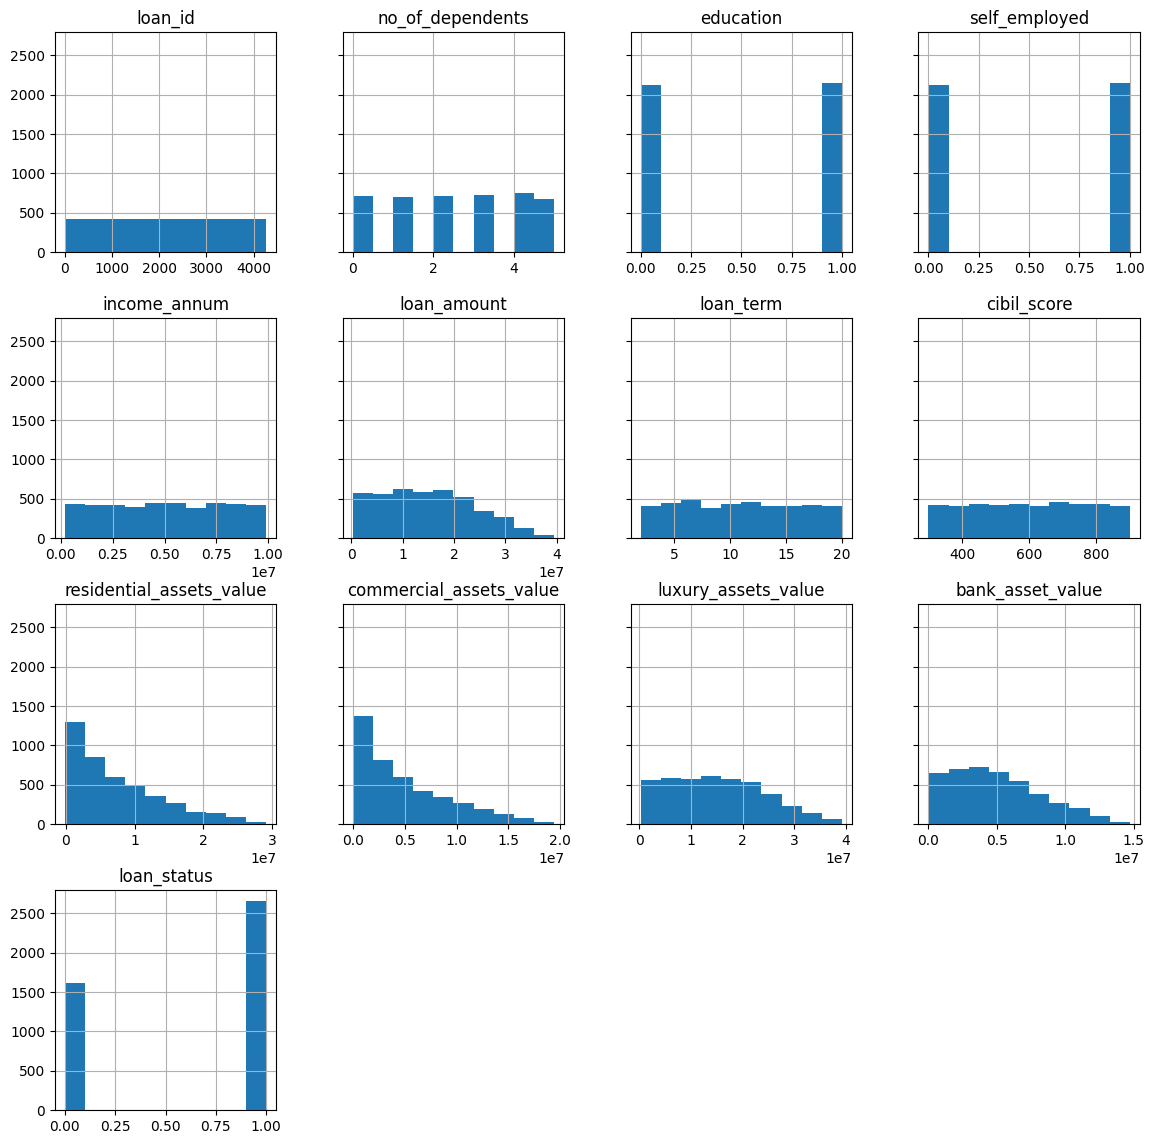

In [189]:
selected = df.iloc[:,:]
selected.hist(figsize=(14,14),sharey=True)

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>]], dtype=object)

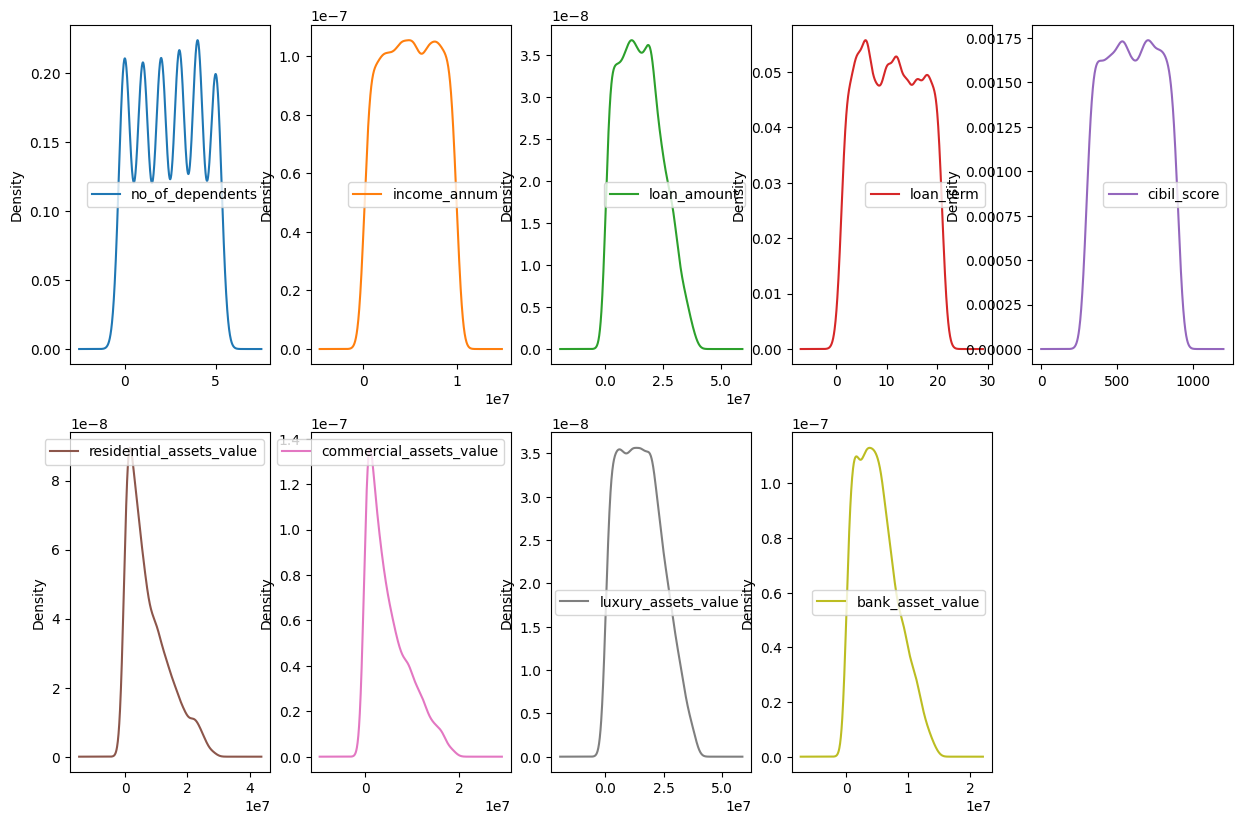

In [190]:
selected = df.loc[:,['no_of_dependents','income_annum','loan_amount','loan_term','cibil_score','residential_assets_value',
                     'commercial_assets_value','luxury_assets_value','bank_asset_value']]
selected.plot(kind='density', subplots=True, layout=(3,5), sharex=False,figsize=(15,15))

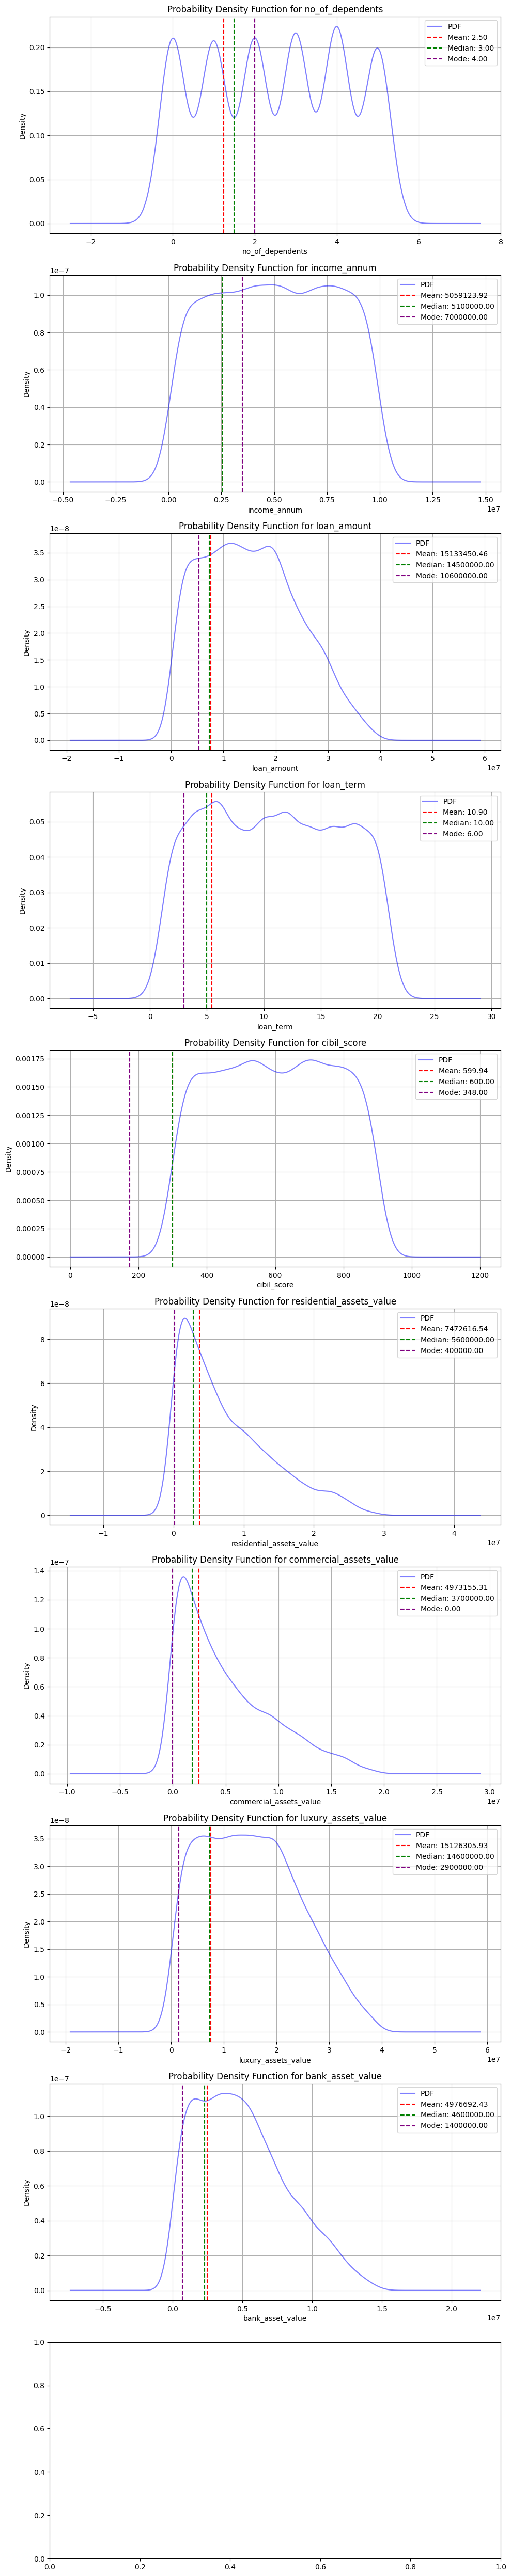

In [191]:
# Setting up the plot
fig, axes = plt.subplots(nrows=10, ncols=1, figsize=(10, 5 * 10))

# Loop through each feature to create a PDF plot
for i, column in enumerate(selected):
    # Plotting the density
    df[column].plot(kind='density', ax=axes[i], color='blue', alpha=0.5, label='PDF')

    # Calculate mean, median, and mode
    mean = df[column].mean()
    median = df[column].median()
    mode = df[column].mode()[0]

    # Marking mean, median, and mode with horizontal lines
    axes[i].axvline(x=mean / 2, color='red', linestyle='--', label=f'Mean: {mean:.2f}')  # Adjusted y-value for visibility
    axes[i].axvline(x=median / 2, color='green', linestyle='--', label=f'Median: {median:.2f}')  # Adjusted y-value for visibility
    axes[i].axvline(x=mode / 2, color='purple', linestyle='--', label=f'Mode: {mode:.2f}')  # Adjusted y-value for visibility

    # Adding titles and labels
    axes[i].set_title(f'Probability Density Function for {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [192]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [193]:
selected.skew()

,0
no_of_dependents,-0.017971
income_annum,-0.012814
loan_amount,0.308724
loan_term,0.036359
cibil_score,-0.009039
residential_assets_value,0.978451
commercial_assets_value,0.957791
luxury_assets_value,0.322208
bank_asset_value,0.560725


## Outliers initial plot

,0
no_of_dependents,"Axes(0.125,0.747241;0.227941x0.132759)"
income_annum,"Axes(0.398529,0.747241;0.227941x0.132759)"
loan_amount,"Axes(0.672059,0.747241;0.227941x0.132759)"
loan_term,"Axes(0.125,0.587931;0.227941x0.132759)"
cibil_score,"Axes(0.398529,0.587931;0.227941x0.132759)"
residential_assets_value,"Axes(0.672059,0.587931;0.227941x0.132759)"
commercial_assets_value,"Axes(0.125,0.428621;0.227941x0.132759)"
luxury_assets_value,"Axes(0.398529,0.428621;0.227941x0.132759)"
bank_asset_value,"Axes(0.672059,0.428621;0.227941x0.132759)"


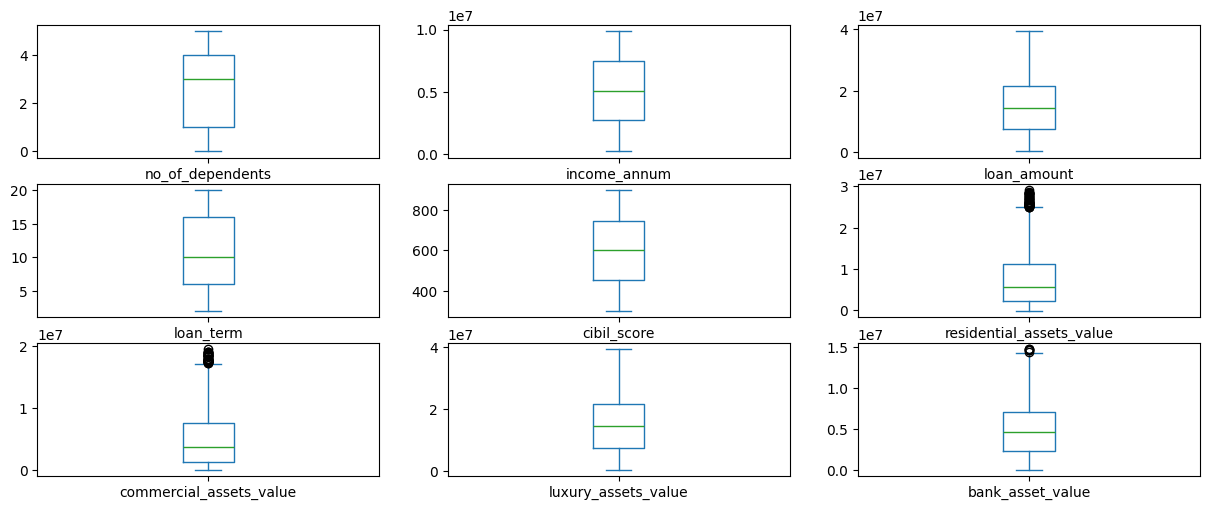

In [194]:
selected.plot(kind='box', subplots=True, sharex=False, sharey=False, layout=(5,3), figsize=(15,10)) #very important to detect outliers that can cause data skew that need to be removed

# **Data Cleaning**

## Dropping unnecessary columns

In [195]:
df = df.drop(columns=["loan_id"]) # loan_id column dropped because it has no significance

## Checking for Null values

In [196]:
df.isnull().sum() # We have NO Null values [(df['A'] == 0).sum()] ?\ should I check for zero values incase of integers ? NO , nothing was
                                                                                  #said about

,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0
luxury_assets_value,0


## Outliers Ilterative removal

In [197]:
Q1 = np.percentile(df['commercial_assets_value'], 25)
Q3 = np.percentile(df['commercial_assets_value'], 75)
IQR = Q3 - Q1
df = df[(df['commercial_assets_value'] >= Q1 - 1.5 * IQR) & (df['commercial_assets_value'] <= Q3 + 1.5 * IQR)] #this will pull the value of the skew closer to 0

,0
no_of_dependents,"Axes(0.125,0.747241;0.227941x0.132759)"
income_annum,"Axes(0.398529,0.747241;0.227941x0.132759)"
loan_amount,"Axes(0.672059,0.747241;0.227941x0.132759)"
loan_term,"Axes(0.125,0.587931;0.227941x0.132759)"
cibil_score,"Axes(0.398529,0.587931;0.227941x0.132759)"
residential_assets_value,"Axes(0.672059,0.587931;0.227941x0.132759)"
commercial_assets_value,"Axes(0.125,0.428621;0.227941x0.132759)"
luxury_assets_value,"Axes(0.398529,0.428621;0.227941x0.132759)"
bank_asset_value,"Axes(0.672059,0.428621;0.227941x0.132759)"


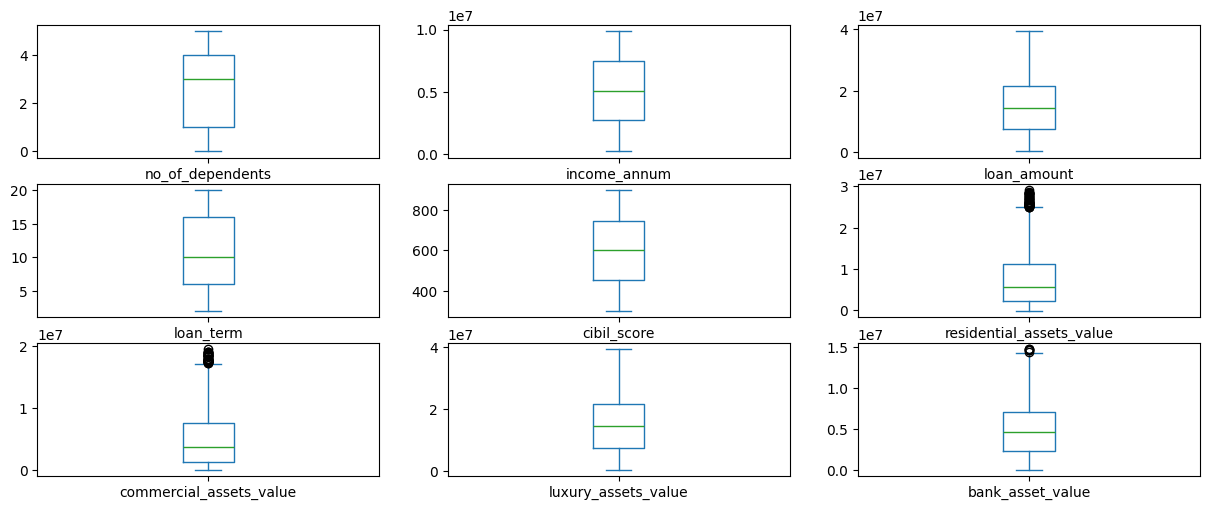

In [198]:
selected.plot(kind='box', subplots=True, sharex=False, sharey=False, layout=(5,3), figsize=(15,10))

In [199]:
Q1 = np.percentile(df['residential_assets_value'], 25)
Q3 = np.percentile(df['residential_assets_value'], 75)
IQR = Q3 - Q1
df = df[(df['residential_assets_value'] >= Q1 - 1.5 * IQR) & (df['residential_assets_value'] <= Q3 + 1.5 * IQR)] #this will pull the value of the skew closer to 0

,0
no_of_dependents,"Axes(0.125,0.747241;0.227941x0.132759)"
education,"Axes(0.398529,0.747241;0.227941x0.132759)"
self_employed,"Axes(0.672059,0.747241;0.227941x0.132759)"
income_annum,"Axes(0.125,0.587931;0.227941x0.132759)"
loan_amount,"Axes(0.398529,0.587931;0.227941x0.132759)"
loan_term,"Axes(0.672059,0.587931;0.227941x0.132759)"
cibil_score,"Axes(0.125,0.428621;0.227941x0.132759)"
residential_assets_value,"Axes(0.398529,0.428621;0.227941x0.132759)"
commercial_assets_value,"Axes(0.672059,0.428621;0.227941x0.132759)"
luxury_assets_value,"Axes(0.125,0.26931;0.227941x0.132759)"


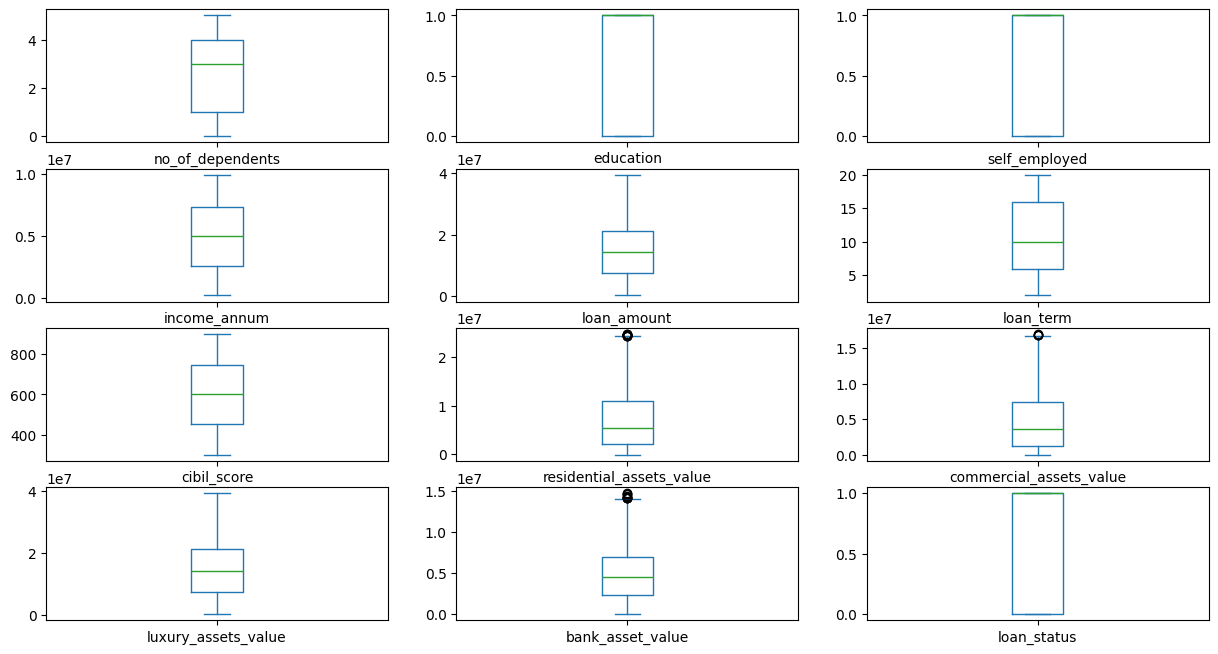

In [200]:
df.plot(kind='box', subplots=True, sharex=False, sharey=False, layout=(5,3), figsize=(15,10))

In [201]:
Q1 = np.percentile(df['bank_asset_value'], 25)
Q3 = np.percentile(df['bank_asset_value'], 75)
IQR = Q3 - Q1
df = df[(df['bank_asset_value'] >= Q1 - 1.5 * IQR) & (df['bank_asset_value'] <= Q3 + 1.5 * IQR)] #this will pull the value of the skew closer to 0

,0
no_of_dependents,"Axes(0.125,0.747241;0.227941x0.132759)"
education,"Axes(0.398529,0.747241;0.227941x0.132759)"
self_employed,"Axes(0.672059,0.747241;0.227941x0.132759)"
income_annum,"Axes(0.125,0.587931;0.227941x0.132759)"
loan_amount,"Axes(0.398529,0.587931;0.227941x0.132759)"
loan_term,"Axes(0.672059,0.587931;0.227941x0.132759)"
cibil_score,"Axes(0.125,0.428621;0.227941x0.132759)"
residential_assets_value,"Axes(0.398529,0.428621;0.227941x0.132759)"
commercial_assets_value,"Axes(0.672059,0.428621;0.227941x0.132759)"
luxury_assets_value,"Axes(0.125,0.26931;0.227941x0.132759)"


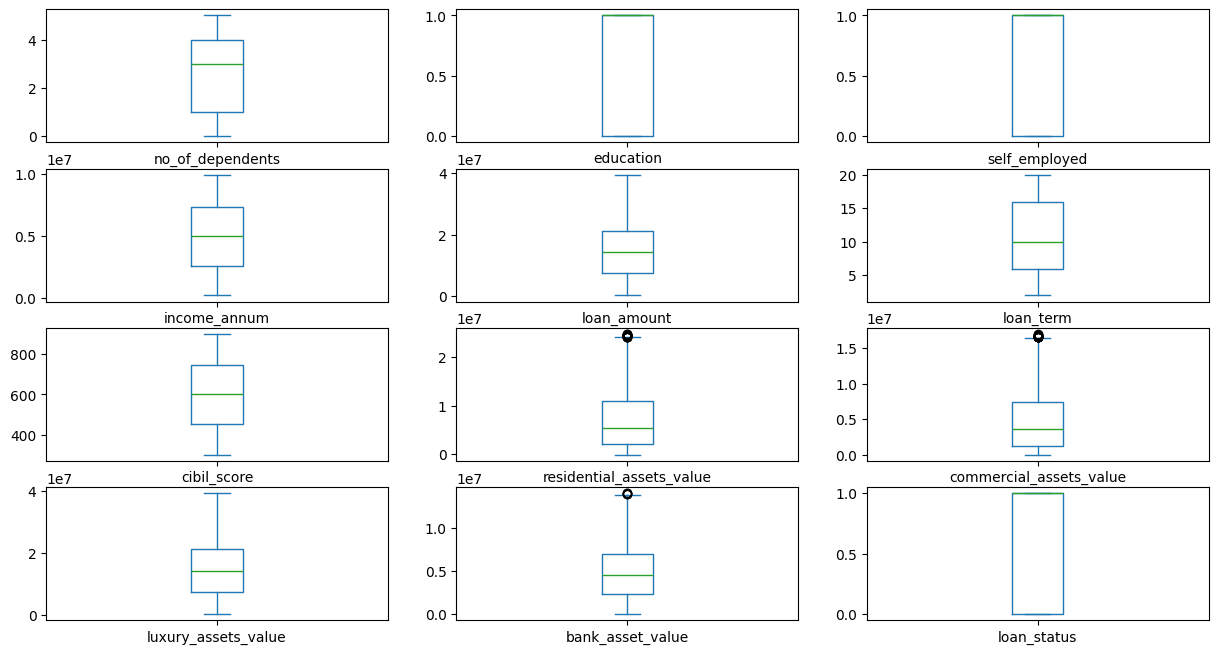

In [202]:
df.plot(kind='box', subplots=True, sharex=False, sharey=False, layout=(5,3), figsize=(15,10))

## **All outliers have been removed**



,0
no_of_dependents,"Axes(0.125,0.747241;0.227941x0.132759)"
education,"Axes(0.398529,0.747241;0.227941x0.132759)"
self_employed,"Axes(0.672059,0.747241;0.227941x0.132759)"
income_annum,"Axes(0.125,0.587931;0.227941x0.132759)"
loan_amount,"Axes(0.398529,0.587931;0.227941x0.132759)"
loan_term,"Axes(0.672059,0.587931;0.227941x0.132759)"
cibil_score,"Axes(0.125,0.428621;0.227941x0.132759)"
residential_assets_value,"Axes(0.398529,0.428621;0.227941x0.132759)"
commercial_assets_value,"Axes(0.672059,0.428621;0.227941x0.132759)"
luxury_assets_value,"Axes(0.125,0.26931;0.227941x0.132759)"


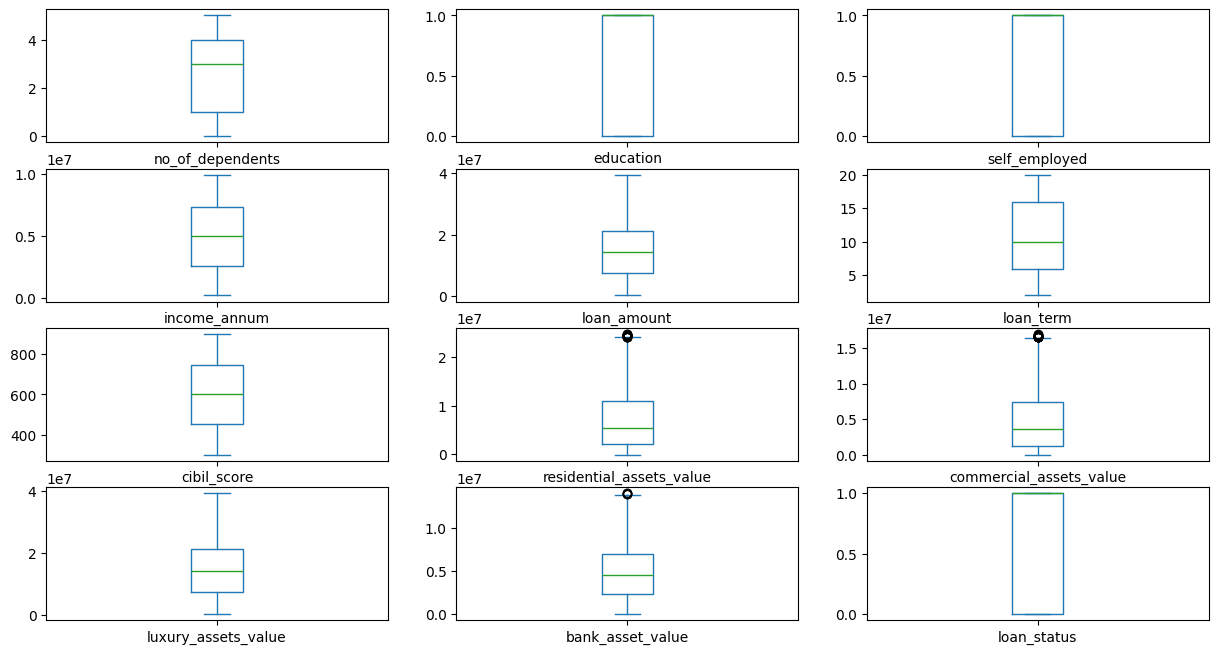

In [203]:
df.plot(kind='box', subplots=True, sharex=False, sharey=False, layout=(5,3), figsize=(15,10))

In [204]:
display(df)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,0.0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1.0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1.0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0.0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,1.0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1.0,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,0,0.0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,2,0.0,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,1,0.0,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


## **Removing Duplicates**

In [205]:
df = df.drop_duplicates()
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,0.0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1.0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1.0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0.0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,1.0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1.0,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,0,0.0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,2,0.0,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,1,0.0,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


## QQ-plots

- Education column was added to show categorical features have no significance in QQ-plots

In [206]:
df.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

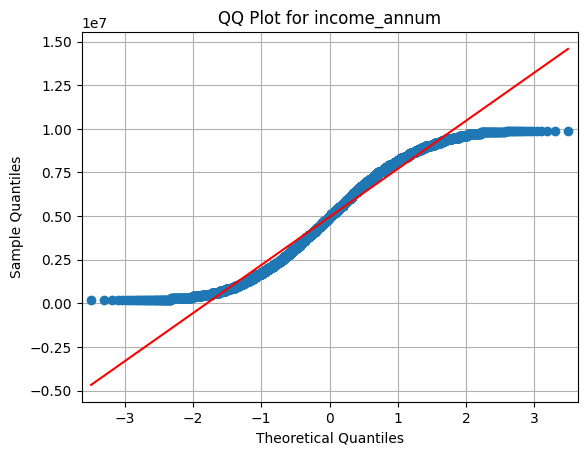

<Figure size 640x480 with 0 Axes>

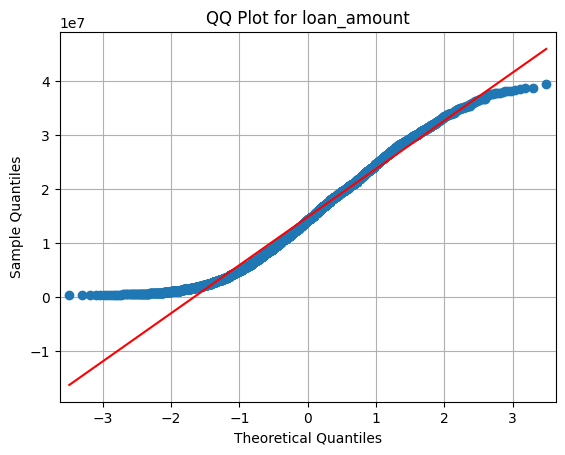

<Figure size 640x480 with 0 Axes>

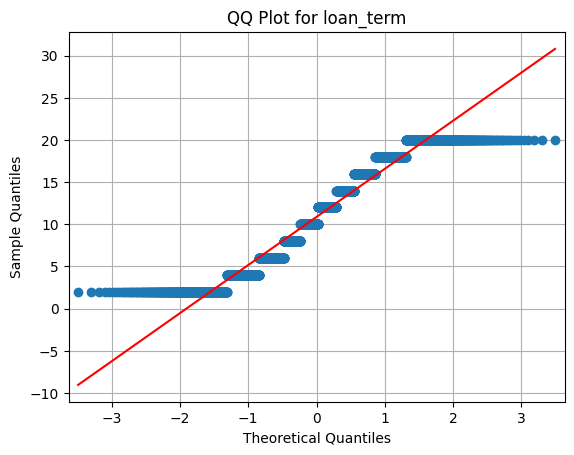

<Figure size 640x480 with 0 Axes>

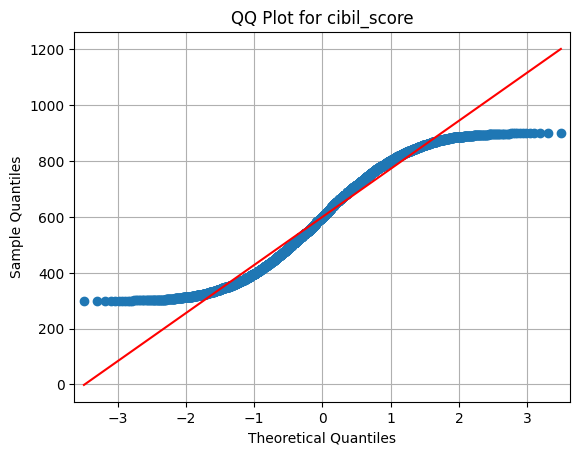

<Figure size 640x480 with 0 Axes>

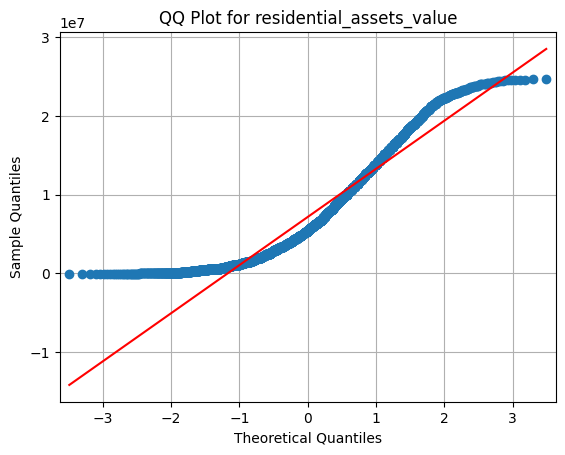

<Figure size 640x480 with 0 Axes>

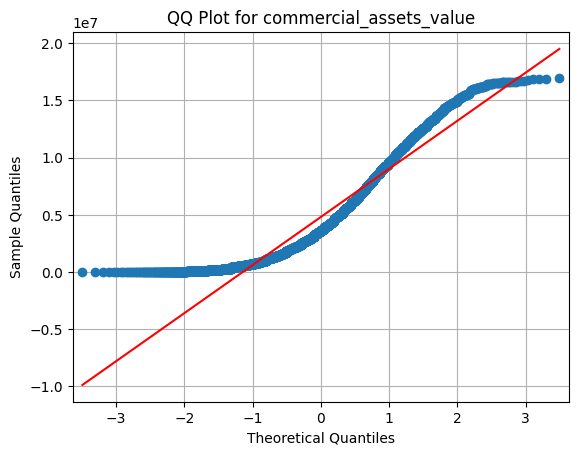

<Figure size 640x480 with 0 Axes>

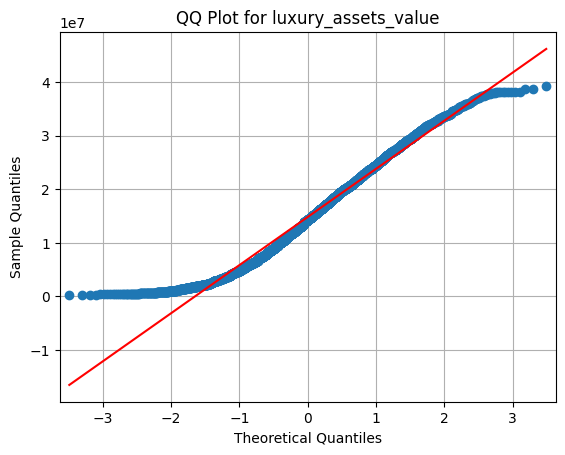

<Figure size 640x480 with 0 Axes>

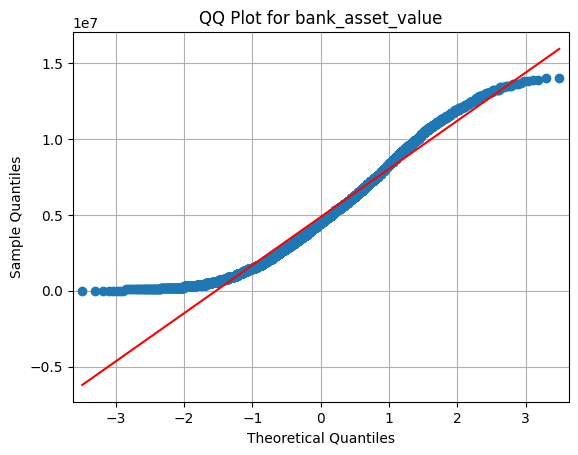

<Figure size 640x480 with 0 Axes>

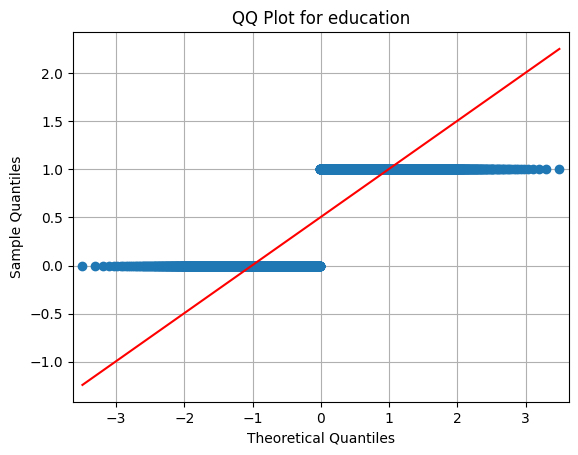

<Figure size 640x480 with 0 Axes>

In [207]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

columns_to_plot = ['income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value',
                   'luxury_assets_value', 'bank_asset_value', 'education']
for col in columns_to_plot:
  # Create the QQ plot for the current column
  fig, ax = plt.subplots()
  sm.qqplot(df[col], line='s', ax=ax)

  # Customize the plot (optional)
  plt.title(f"QQ Plot for {col}")
  plt.xlabel("Theoretical Quantiles")
  plt.ylabel("Sample Quantiles")
  plt.grid(True)

  # Show the plot (you can also save it to a file or subplot)
  plt.show()

  # Clear the plot for the next iteration (optional)
  plt.clf()

# **Feature Selection**

## Correlation **detection**

In [208]:
data = df[['no_of_dependents','income_annum','loan_amount','loan_term','cibil_score','residential_assets_value',
                     'commercial_assets_value','luxury_assets_value','bank_asset_value']]
correlation_matrix = data.corr() #calculating correlation coeffecients between different features
correlation_matrix

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
no_of_dependents,1.000000,0.009889,-0.003850,-0.020257,-0.010511,0.015181,-0.001856,0.005567,0.011546
income_annum,0.009889,1.000000,0.928178,0.006439,-0.021412,0.625877,0.636870,0.929973,0.851445
loan_amount,-0.003850,0.928178,1.000000,0.004938,-0.015362,0.591361,0.598955,0.863626,0.789933
loan_term,-0.020257,0.006439,0.004938,1.000000,0.007356,0.001606,-0.011353,0.006363,0.014100
cibil_score,-0.010511,-0.021412,-0.015362,0.007356,1.000000,-0.025139,0.005987,-0.025900,-0.017563
residential_assets_value,0.015181,0.625877,0.591361,0.001606,-0.025139,1.000000,0.414945,0.584282,0.521612
commercial_assets_value,-0.001856,0.636870,0.598955,-0.011353,0.005987,0.414945,1.000000,0.591812,0.549239
luxury_assets_value,0.005567,0.929973,0.863626,0.006363,-0.025900,0.584282,0.591812,1.000000,0.788861
bank_asset_value,0.011546,0.851445,0.789933,0.014100,-0.017563,0.521612,0.549239,0.788861,1.000000


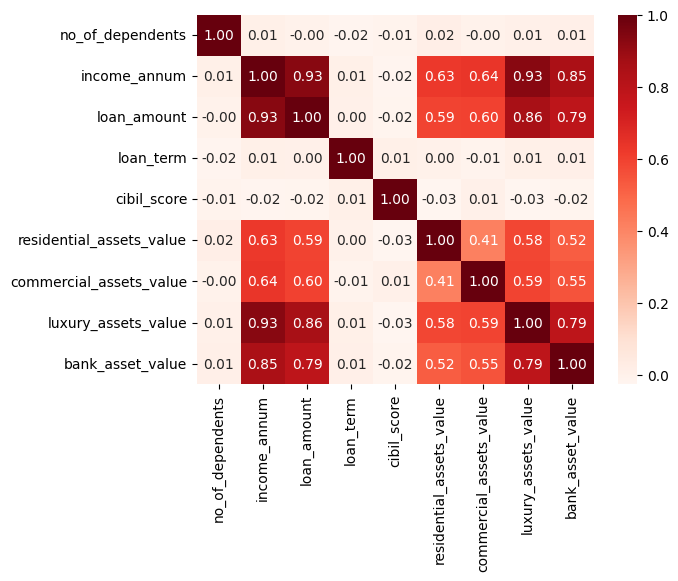

In [209]:
sns.heatmap(correlation_matrix, cmap='Reds', annot=True, fmt='.2f')

plt.show()

<Axes: xlabel='luxury_assets_value', ylabel='income_annum'>

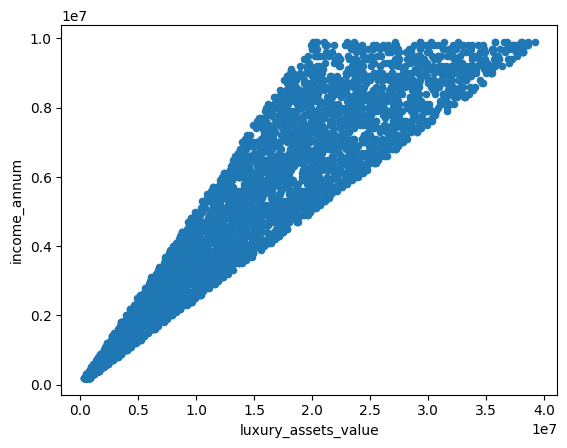

In [210]:
df.plot(kind='scatter', x='luxury_assets_value',y='income_annum')

In [211]:
df_cleared_relation = df.drop(columns=["income_annum" , "loan_amount", "luxury_assets_value"])

In [212]:
data = df_cleared_relation[['no_of_dependents','loan_term','cibil_score','residential_assets_value',
                     'commercial_assets_value','bank_asset_value']]
correlation_matrix = data.corr() #calculating correlation coeffecients between different features
correlation_matrix

,no_of_dependents,loan_term,cibil_score,residential_assets_value,commercial_assets_value,bank_asset_value
no_of_dependents,1.000000,-0.020257,-0.010511,0.015181,-0.001856,0.011546
loan_term,-0.020257,1.000000,0.007356,0.001606,-0.011353,0.014100
cibil_score,-0.010511,0.007356,1.000000,-0.025139,0.005987,-0.017563
residential_assets_value,0.015181,0.001606,-0.025139,1.000000,0.414945,0.521612
commercial_assets_value,-0.001856,-0.011353,0.005987,0.414945,1.000000,0.549239
bank_asset_value,0.011546,0.014100,-0.017563,0.521612,0.549239,1.000000


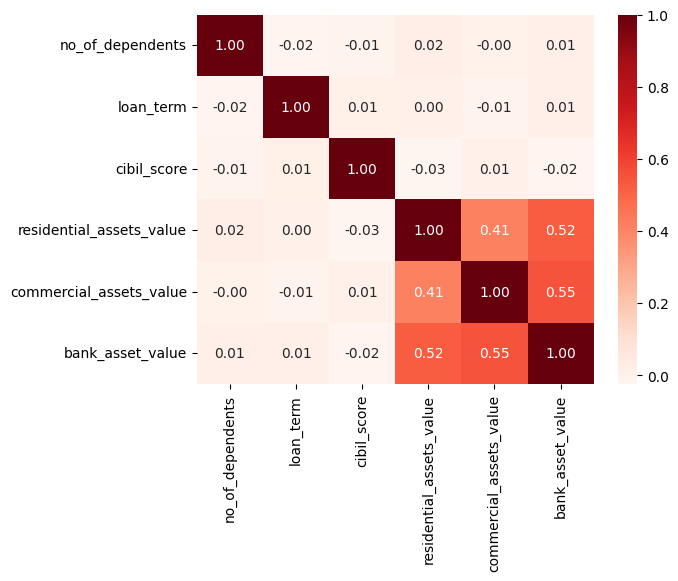

In [213]:
sns.heatmap(correlation_matrix, cmap='Reds', annot=True, fmt='.2f')

plt.show()

# Splitting data into train and test (80% - 20%) and normalization using StandardScaler


In [214]:
X = df.drop(columns=['loan_amount','loan_status','income_annum','luxury_assets_value']).values #drop the colerated features + the output features

y = df[['loan_status']].values # choose the regression feature

In [215]:
X.shape

(4168, 8)

In [216]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)
X_train_val, X_val, y_train_val, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=42)

In [217]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [218]:
df.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

In [219]:
X_train=pd.DataFrame(X_train,columns=df.drop(columns=['loan_amount','loan_status','income_annum','luxury_assets_value']).columns)

In [220]:
print(y_train)

[[1]
 [1]
 [1]
 ...
 [1]
 [1]
 [0]]


In [221]:
X_train.head()

,no_of_dependents,education,self_employed,loan_term,cibil_score,residential_assets_value,commercial_assets_value,bank_asset_value
0,-0.311621,0.993423,1.003606,-0.154908,0.430816,0.648843,0.898203,0.048929
1,-1.494257,0.993423,-0.996407,1.247571,-0.154761,-0.942138,-0.912423,-1.440985
2,-0.902939,-1.006621,1.003606,1.598190,0.749694,-1.007745,-0.388294,-1.092281
3,-1.494257,0.993423,-0.996407,-1.557386,0.836661,2.223421,0.922027,1.507143
4,0.871014,0.993423,1.003606,-1.206767,-1.610007,0.484824,-1.126839,0.651235


In [222]:
X_train.describe()

,no_of_dependents,education,self_employed,loan_term,cibil_score,residential_assets_value,commercial_assets_value,bank_asset_value
count,3.334000e+03,3.334000e+03,3.334000e+03,3.334000e+03,3.334000e+03,3.334000e+03,3.334000e+03,3.334000e+03
mean,7.885447e-17,-2.823843e-17,-1.065601e-16,5.328005e-19,-1.236097e-16,2.024642e-17,2.610722e-17,5.114885e-17
std,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00
min,-1.494257e+00,-1.006621e+00,-9.964072e-01,-1.557386e+00,-1.731761e+00,-1.188166e+00,-1.150663e+00,-1.536085e+00
25%,-9.029389e-01,-1.006621e+00,-9.964072e-01,-8.561472e-01,-8.548448e-01,-8.396261e-01,-8.409508e-01,-8.069787e-01
50%,2.796964e-01,9.934229e-01,-9.964072e-01,-1.549078e-01,7.576779e-03,-2.696615e-01,-2.691743e-01,-1.095723e-01
75%,8.710141e-01,9.934229e-01,1.003606e+00,8.969511e-01,8.482567e-01,6.160389e-01,6.123145e-01,6.195344e-01
max,1.462332e+00,9.934229e-01,1.003606e+00,1.598190e+00,1.746914e+00,2.879495e+00,2.875597e+00,2.901955e+00


#PCA

## Principal Component Analysis (PCA) exploratory analysis

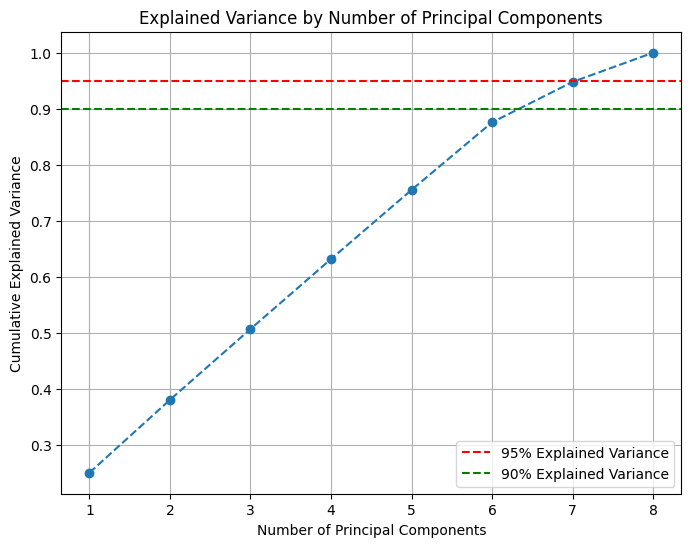

In [223]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Example data (replace with your dataset)
# X = your_dataset

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Fit PCA
pca = PCA()
pca.fit(X_scaled)

# Calculate explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Explained Variance by Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% Explained Variance')
plt.legend(loc='best')
plt.grid()
plt.show()


###we choose the 90% variance which is 7

## PCA = 2

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


Explained Variance Ratio:
 [0.25060763 0.13005857]


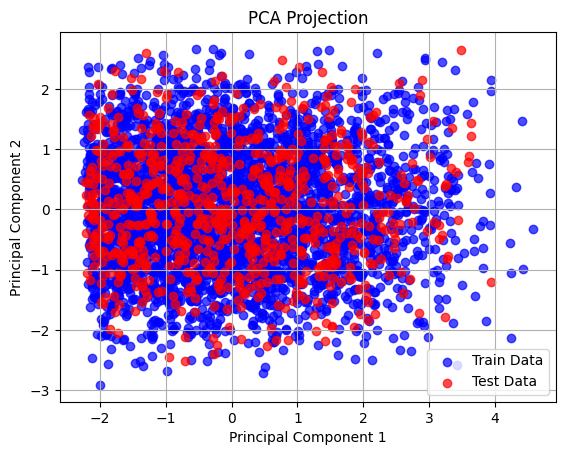

In [224]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
X_trainPCA = pca.fit_transform(X_train)
X_testPCA = pca.transform(X_test)


explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:\n", explained_variance)


plt.scatter(X_trainPCA[:, 0], X_trainPCA[:, 1], c='blue', alpha=0.7, label="Train Data")
plt.scatter(X_testPCA[:, 0], X_testPCA[:, 1], c='red', alpha=0.7, label="Test Data")

plt.title('PCA Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid()
plt.show()



##PCA = 6

In [254]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 7)
X_trainPCA6 = pca.fit_transform(X_train)
X_testPCA6 = pca.transform(X_test)

# Since we have 6 components, a plot won't be feasible.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


#Clustering

## Using the elbow method to find the optimal number of clusters

## Reasoning behind clustering count :-

1- For 4 clusters the Davis Bouldin Index is less than 2 clusters

2- For 4 clusters the Silhouette Score is more than 2 clusters

3- Elbow method showed that 4 clusters is relatively the best




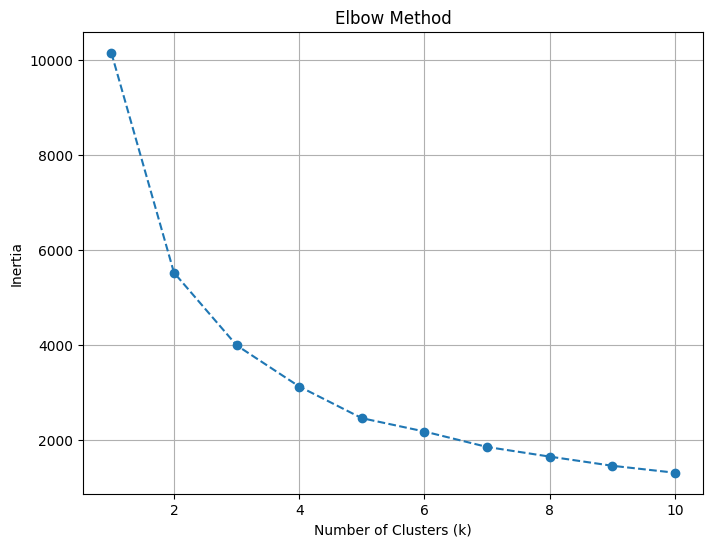

In [255]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate inertia for a range of cluster sizes
inertia_values = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_trainPCA)  # Use PCA-transformed data
    inertia_values.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia_values, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid()
plt.show()


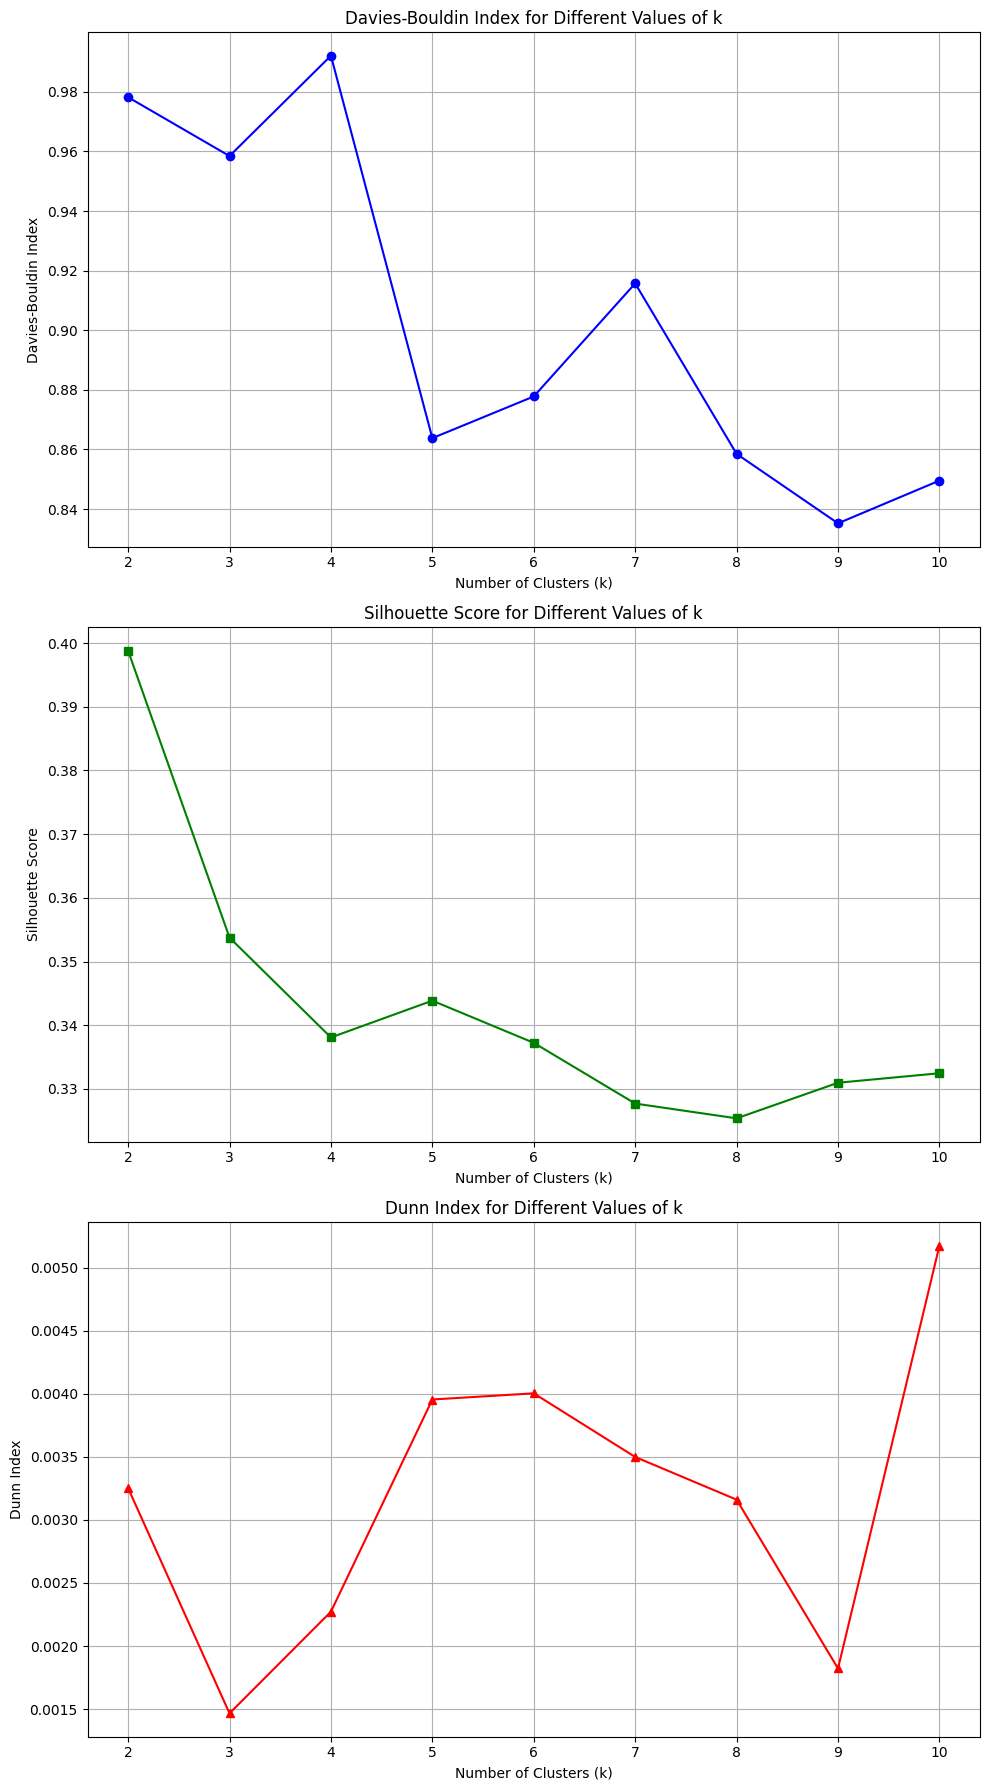

K=2, Davies-Bouldin Index: 0.9782186684594008, Silhouette Score: 0.3987986911558916, Dunn Index: 0.00325233042478957
K=3, Davies-Bouldin Index: 0.9584759620233352, Silhouette Score: 0.3537611386555612, Dunn Index: 0.001465971920254958
K=4, Davies-Bouldin Index: 0.9921491328533387, Silhouette Score: 0.33808091326311906, Dunn Index: 0.0022722175980500942
K=5, Davies-Bouldin Index: 0.8637923183848505, Silhouette Score: 0.3438564335150654, Dunn Index: 0.003954995885327195
K=6, Davies-Bouldin Index: 0.8777810941967656, Silhouette Score: 0.3372364124301028, Dunn Index: 0.004003931630425493
K=7, Davies-Bouldin Index: 0.9157239452422744, Silhouette Score: 0.3277000421313392, Dunn Index: 0.00349926913882343
K=8, Davies-Bouldin Index: 0.8585166933988171, Silhouette Score: 0.3253820130014261, Dunn Index: 0.003160707181558545
K=9, Davies-Bouldin Index: 0.8351959400213718, Silhouette Score: 0.3309714320801657, Dunn Index: 0.0018217132521633835
K=10, Davies-Bouldin Index: 0.849542660506169, Silhouet

In [256]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
from scipy.spatial.distance import cdist

# Assuming X_trainPCA is your dataset

# Range of k values to test (e.g., from 2 to 10)
k_range = range(2, 11)

# Lists to store the values of DBI, Dunn, and Silhouette scores
dbi_values = []
silhouette_values = []
dunn_values = []

# Calculate Dunn Index
def dunn_index(X, labels):
    # Number of clusters
    n_clusters = len(np.unique(labels))

    # Initialize variables
    inter_cluster_distances = []
    intra_cluster_distances = []

    for i in range(n_clusters):
        # Points belonging to cluster i
        cluster_points = X[labels == i]

        # Calculate the maximum intra-cluster distance (diameter of the cluster)
        intra_cluster_distances.append(np.max(cdist(cluster_points, cluster_points)))

        for j in range(i + 1, n_clusters):
            # Points belonging to cluster j
            cluster_j_points = X[labels == j]

            # Calculate the minimum inter-cluster distance (distance between clusters)
            inter_cluster_distances.append(np.min(cdist(cluster_points, cluster_j_points)))

    # Dunn Index = min(inter-cluster distance) / max(intra-cluster distance)
    return np.min(inter_cluster_distances) / np.max(intra_cluster_distances)

# Loop through different k values to calculate DBI, Dunn Index, and Silhouette Score
for k in k_range:
    kmeans = KMeans(n_clusters=k)
    kmeans_labels = kmeans.fit_predict(X_trainPCA)

    # Compute Davies-Bouldin Index for the current k
    dbi = davies_bouldin_score(X_trainPCA, kmeans_labels)
    dbi_values.append(dbi)

    # Compute Silhouette Score for the current k
    silhouette = silhouette_score(X_trainPCA, kmeans_labels)
    silhouette_values.append(silhouette)

    # Compute Dunn Index for the current k
    dunn = dunn_index(X_trainPCA, kmeans_labels)
    dunn_values.append(dunn)

# Create subplots to display three separate graphs
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# Davies-Bouldin Index plot
axes[0].plot(k_range, dbi_values, marker='o', linestyle='-', color='b')
axes[0].set_title('Davies-Bouldin Index for Different Values of k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Davies-Bouldin Index')
axes[0].grid(True)
axes[0].set_xticks(k_range)

# Silhouette Score plot
axes[1].plot(k_range, silhouette_values, marker='s', linestyle='-', color='g')
axes[1].set_title('Silhouette Score for Different Values of k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)
axes[1].set_xticks(k_range)

# Dunn Index plot
axes[2].plot(k_range, dunn_values, marker='^', linestyle='-', color='r')
axes[2].set_title('Dunn Index for Different Values of k')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Dunn Index')
axes[2].grid(True)
axes[2].set_xticks(k_range)

# Adjust layout and display
plt.tight_layout()
plt.show()

# Print the evaluation scores for each k
for k, dbi, silhouette, dunn in zip(k_range, dbi_values, silhouette_values, dunn_values):
    print(f"K={k}, Davies-Bouldin Index: {dbi}, Silhouette Score: {silhouette}, Dunn Index: {dunn}")


###We choose k=4 as has high Silhouette and max Davies-Bouldin and elbow method.


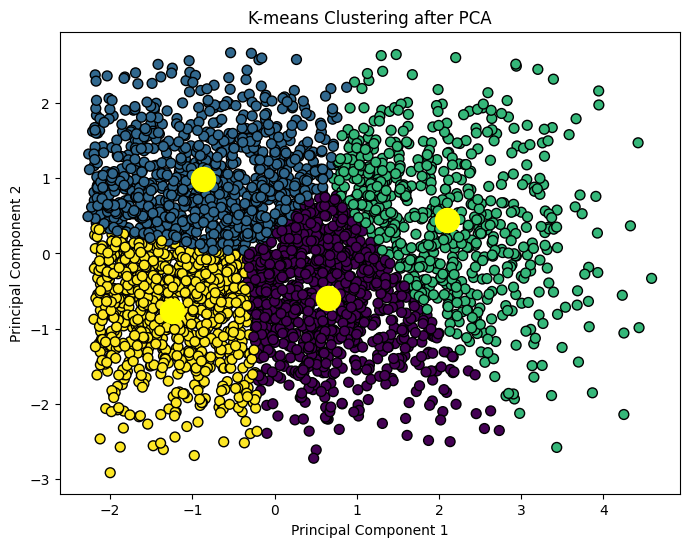

K-means - Davies–Bouldin index: 0.9911259247428277
K-means - Silhouette Score: 0.33808908604237126
K-means - Dunn Index: 0.0022722175980500942


In [257]:
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k)
kmeans_labels = kmeans.fit_predict(X_trainPCA)

# Davies–Bouldin index
dbi_kmeans = davies_bouldin_score(X_trainPCA, kmeans_labels)

# Silhouette score
silhouette_kmeans = silhouette_score(X_trainPCA, kmeans_labels)
# Calculate Dunn Index
def dunn_index(X, labels):
    # Number of clusters
    n_clusters = len(np.unique(labels))

    # Initialize variables
    inter_cluster_distances = []
    intra_cluster_distances = []

    for i in range(n_clusters):
        # Points belonging to cluster i
        cluster_points = X[labels == i]

        # Calculate the maximum intra-cluster distance (diameter of the cluster)
        intra_cluster_distances.append(np.max(cdist(cluster_points, cluster_points)))

        for j in range(i + 1, n_clusters):
            # Points belonging to cluster j
            cluster_j_points = X[labels == j]

            # Calculate the minimum inter-cluster distance (distance between clusters)
            inter_cluster_distances.append(np.min(cdist(cluster_points, cluster_j_points)))

    # Dunn Index = min(inter-cluster distance) / max(intra-cluster distance)
    return np.min(inter_cluster_distances) / np.max(intra_cluster_distances)

# Calculate Dunn Index
dunn_kmeans = dunn_index(X_trainPCA, kmeans_labels)

# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_train)
plt.figure(figsize=(8, 6))

plt.scatter(X_trainPCA[:, 0], X_trainPCA[:, 1], c=kmeans_labels, cmap='viridis', edgecolors='k', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids')

plt.title('K-means Clustering after PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()
print(f"K-means - Davies–Bouldin index: {dbi_kmeans}")
print(f"K-means - Silhouette Score: {silhouette_kmeans}")
print(f"K-means - Dunn Index: {dunn_kmeans}")



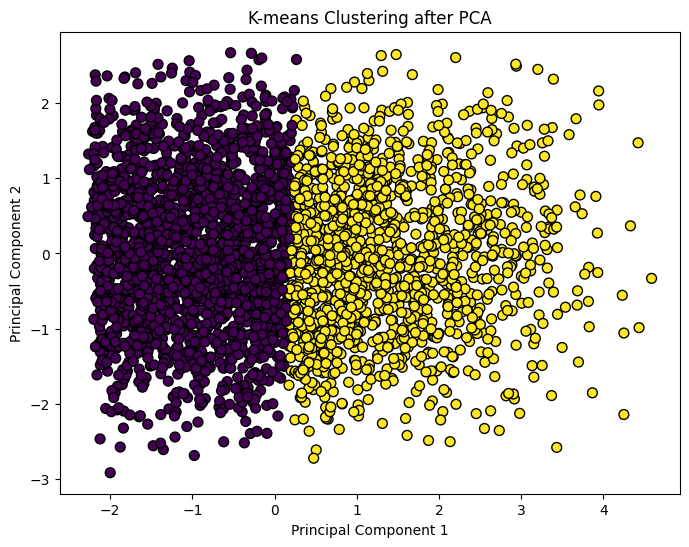

K-means - Davies–Bouldin index: 0.9783167509779613
K-means - Silhouette Score: 0.39875028923220673
K-means - Dunn Index: 0.00325233042478957


In [258]:
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

optimal_k = 2

kmeans = KMeans(n_clusters=optimal_k)
kmeans_labels = kmeans.fit_predict(X_trainPCA)

# Davies–Bouldin index
dbi_kmeans = davies_bouldin_score(X_trainPCA, kmeans_labels)

# Silhouette score
silhouette_kmeans = silhouette_score(X_trainPCA, kmeans_labels)
# Calculate Dunn Index
def dunn_index(X, labels):
    # Number of clusters
    n_clusters = len(np.unique(labels))

    # Initialize variables
    inter_cluster_distances = []
    intra_cluster_distances = []

    for i in range(n_clusters):
        # Points belonging to cluster i
        cluster_points = X[labels == i]

        # Calculate the maximum intra-cluster distance (diameter of the cluster)
        intra_cluster_distances.append(np.max(cdist(cluster_points, cluster_points)))

        for j in range(i + 1, n_clusters):
            # Points belonging to cluster j
            cluster_j_points = X[labels == j]

            # Calculate the minimum inter-cluster distance (distance between clusters)
            inter_cluster_distances.append(np.min(cdist(cluster_points, cluster_j_points)))

    # Dunn Index = min(inter-cluster distance) / max(intra-cluster distance)
    return np.min(inter_cluster_distances) / np.max(intra_cluster_distances)

# Calculate Dunn Index
dunn_kmeans = dunn_index(X_trainPCA, kmeans_labels)

# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_train)
plt.figure(figsize=(8, 6))

plt.scatter(X_trainPCA[:, 0], X_trainPCA[:, 1], c=kmeans_labels, cmap='viridis', edgecolors='k', s=50)
plt.title('K-means Clustering after PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()
print(f"K-means - Davies–Bouldin index: {dbi_kmeans}")
print(f"K-means - Silhouette Score: {silhouette_kmeans}")
print(f"K-means - Dunn Index: {dunn_kmeans}")



# Training the Model



In [259]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train
clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9028776978417267
Confusion Matrix:
 [[267  41]
 [ 40 486]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87       308
           1       0.92      0.92      0.92       526

    accuracy                           0.90       834
   macro avg       0.90      0.90      0.90       834
weighted avg       0.90      0.90      0.90       834



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [261]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Decision Tree:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Decision Tree:
Accuracy: 0.9580335731414868
Confusion Matrix:
 [[297  11]
 [ 24 502]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.94       308
           1       0.98      0.95      0.97       526

    accuracy                           0.96       834
   macro avg       0.95      0.96      0.96       834
weighted avg       0.96      0.96      0.96       834



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [262]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest:
Accuracy: 0.960431654676259
Confusion Matrix:
 [[296  12]
 [ 21 505]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95       308
           1       0.98      0.96      0.97       526

    accuracy                           0.96       834
   macro avg       0.96      0.96      0.96       834
weighted avg       0.96      0.96      0.96       834



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [263]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Gradient Boosting:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Gradient Boosting:
Accuracy: 0.9484412470023981
Confusion Matrix:
 [[297  11]
 [ 32 494]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93       308
           1       0.98      0.94      0.96       526

    accuracy                           0.95       834
   macro avg       0.94      0.95      0.95       834
weighted avg       0.95      0.95      0.95       834



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [264]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("XGBoost:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [00:10:56] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost:
Accuracy: 0.9592326139088729
Confusion Matrix:
 [[298  10]
 [ 24 502]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95       308
           1       0.98      0.95      0.97       526

    accuracy                           0.96       834
   macro avg       0.95      0.96      0.96       834
weighted avg       0.96      0.96      0.96       834



#Linear Regression without PCA

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X=X_train,y=y_train)

LinearRegression()

##Linear regression Residual Plot and Density graph

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



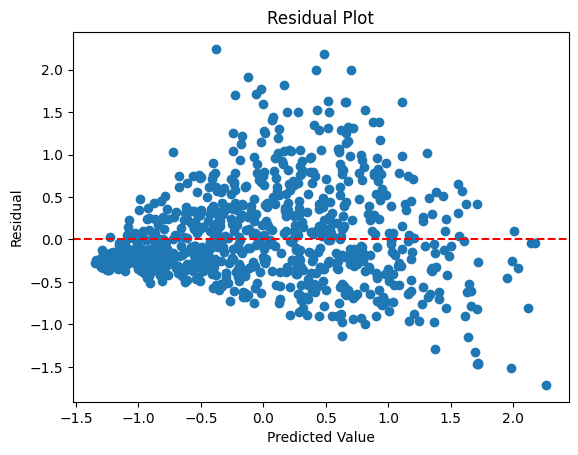

In [ ]:
predictions = model.predict(X_test)
residuals = y_test - predictions

plt.scatter(predictions, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Value")
plt.ylabel("Residual")
plt.show()


<ipython-input-532-77be03960dcb>:5: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




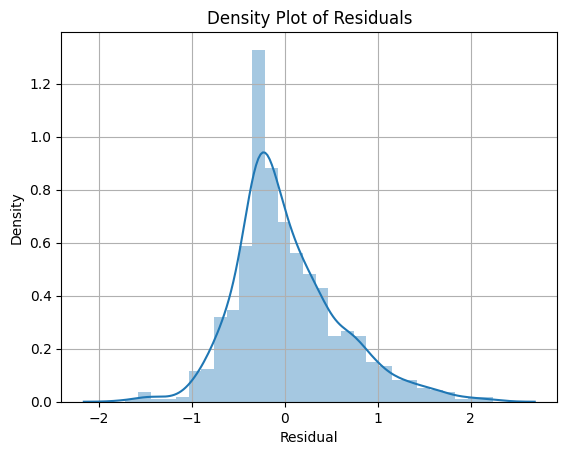

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.distplot(residuals)

plt.title("Density Plot of Residuals")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.grid(True)

plt.show()

## Printing the intercept,**Coeffecients**

In [ ]:
intercept = model.intercept_
coeffecients = model.coef_

print("interept: , coeffecient: ",intercept,coeffecients)

interept: , coeffecient:  [-2.78243344e-17] [[-0.01775974  0.00081394 -0.00733883 -0.00306337  0.21018059  0.17802747
   0.58786645 -0.00239714  0.00239714]]


##Evaluation using MSE, MAE and RMSE errors

In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(model.predict(X_test),y_test)
print(mse)

0.3225367742731662


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



In [ ]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(model.predict(X_test),y_test)
print(mae)

0.43062489607307275


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



In [ ]:
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(model.predict(X_test),y_test)
print(rmse)

0.5679232115992146


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



In [ ]:
avg = df[' loan_amount'].mean()
print((rmse/avg) * 100)

3.872664359224768e-06


#Linear Regression with PCA = 2



In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X=X_trainPCA,y=y_train)

LinearRegression()

##Linear regression Residual Plot and Density graph

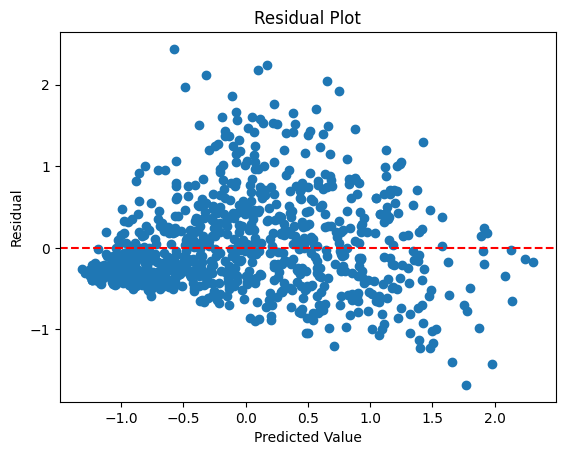

In [ ]:
predictions = model.predict(X_testPCA)
residuals = y_test - predictions

plt.scatter(predictions, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Value")
plt.ylabel("Residual")
plt.show()


<ipython-input-540-77be03960dcb>:5: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




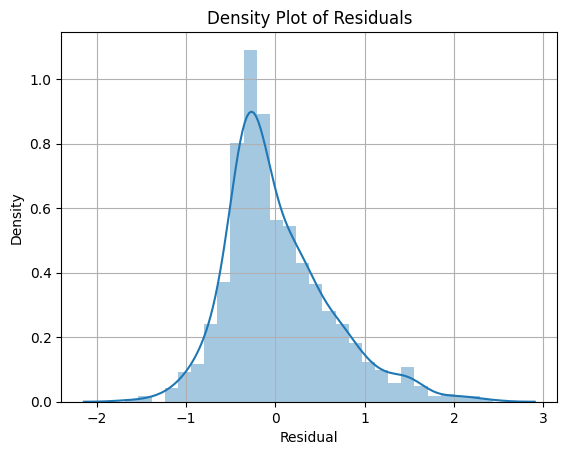

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.distplot(residuals)

plt.title("Density Plot of Residuals")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.grid(True)

plt.show()

## Printing the intercept,**Coeffecients**

In [ ]:
intercept = model.intercept_
coeffecients = model.coef_

print("interept: , coeffecient: ",intercept,coeffecients)

interept: , coeffecient:  [4.05079912e-17] [[0.4787389  0.31467592]]


##Evaluation using MSE, MAE and RMSE errors

In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(model.predict(X_testPCA),y_test)
print(mse)

0.3525071851592475


In [ ]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(model.predict(X_testPCA),y_test)
print(mae)

0.45483970856827505


In [ ]:
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(model.predict(X_testPCA),y_test)
print(rmse)

0.5937231553167246


In [ ]:
avg = df[' loan_amount'].mean()
print((rmse/avg) * 100)

4.048593992781138e-06


#Linear Regression with PCA = 2 Visualization of the regression boundary

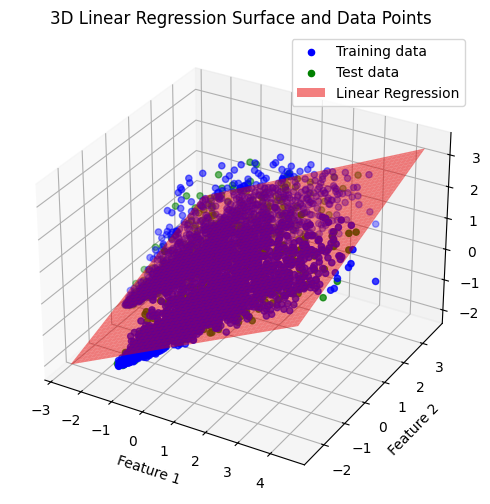

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D


model = LinearRegression()
model.fit(X_trainPCA, y_train)

X_range1 = np.linspace(min(X_trainPCA[:, 0].min(), X_testPCA[:, 0].min()), max(X_trainPCA[:, 0].max(), X_testPCA[:, 0].max()), 100)
X_range2 = np.linspace(min(X_trainPCA[:, 1].min(), X_testPCA[:, 1].min()), max(X_trainPCA[:, 1].max(), X_testPCA[:, 1].max()), 100)

X1, X2 = np.meshgrid(X_range1, X_range2)
X_range = np.vstack([X1.ravel(), X2.ravel()]).T

y_range_pred = model.predict(X_range).reshape(X1.shape)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')


ax.scatter(X_trainPCA[:, 0], X_trainPCA[:, 1], y_train, color='blue', label='Training data')

ax.scatter(X_testPCA[:, 0], X_testPCA[:, 1], y_test, color='green', label='Test data')

ax.plot_surface(X1, X2, y_range_pred, color='red', alpha=0.5, label='Linear Regression')

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Target y')
ax.set_title('3D Linear Regression Surface and Data Points')


ax.legend()

plt.show()


#Linear Regression with PCA = 6



In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X=X_trainPCA6,y=y_train)

LinearRegression()

##Linear regression Residual Plot and Density graph

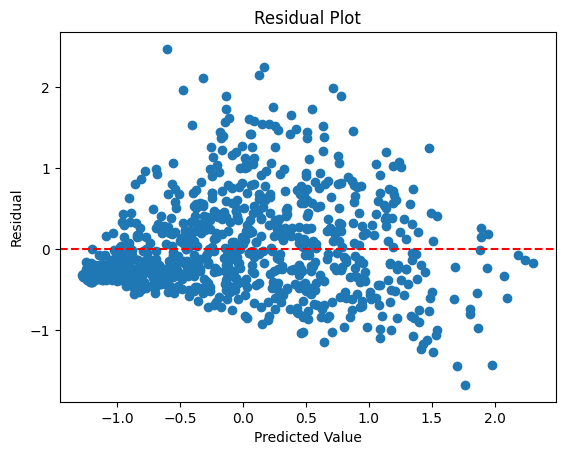

In [ ]:
predictions = model.predict(X_testPCA6)
residuals = y_test - predictions

plt.scatter(predictions, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Value")
plt.ylabel("Residual")
plt.show()


<ipython-input-549-77be03960dcb>:5: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




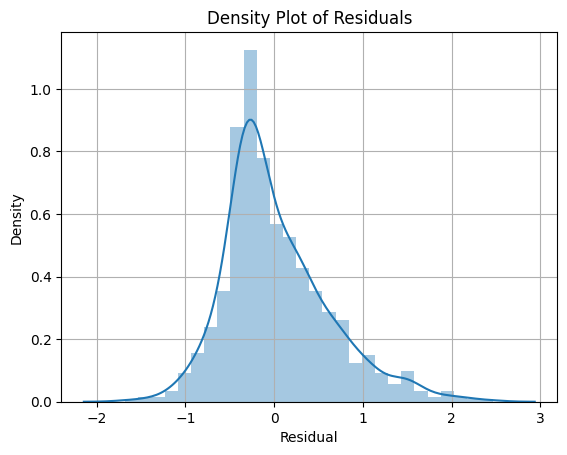

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.distplot(residuals)

plt.title("Density Plot of Residuals")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.grid(True)

plt.show()

## Printing the intercept,**Coeffecients**

In [ ]:
intercept = model.intercept_
coeffecients = model.coef_

print("interept: , coeffecient: ",intercept,coeffecients)

interept: , coeffecient:  [3.97227026e-17] [[ 0.4787389   0.31467592 -0.01818645  0.01060326  0.00372425 -0.03157589]]


##Evaluation using MSE, MAE and RMSE errors

In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(model.predict(X_testPCA6),y_test)
print(mse)

0.3530034610764041


In [ ]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(model.predict(X_testPCA6),y_test)
print(mae)

0.45519943286015085


In [ ]:
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(model.predict(X_testPCA6),y_test)
print(rmse)

0.5941409437805175


In [ ]:
avg = df[' loan_amount'].mean()
print((rmse/avg) * 100)

4.051442889357965e-06


#polynomial regression without PCA

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
best_degree = 0
best_score = float("inf")

for degree in range(1, 10):  # Test polynomial degrees from 1 to 9
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_train)

    model = LinearRegression()
    model.fit(X_poly, y_train)

    X_val_poly = poly.transform(X_test)
    y_pred = model.predict(X_val_poly)
    MSE = mean_squared_error(y_test, y_pred)
    MAE = mean_absolute_error(y_test, y_pred)
    RMSE = root_mean_squared_error(y_test, y_pred)

    print(f"Degree: {degree}, MSE: {MSE} ,MAE: {MAE} ,RMSE: {RMSE}")

    if RMSE < best_score:
        best_score = RMSE
        best_degree = degree

print(f"Best degree: {best_degree}")

Degree: 1, MSE: 0.3225328222121256 ,MAE: 0.4306062301981171 ,RMSE: 0.5679197321912011
Degree: 2, MSE: 0.2806017527318081 ,MAE: 0.39766889421632323 ,RMSE: 0.5297185599276356
Degree: 3, MSE: 0.28665271755316063 ,MAE: 0.40064403019941786 ,RMSE: 0.5353995868070507


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names



Degree: 4, MSE: 0.33879854375359536 ,MAE: 0.43261209215109475 ,RMSE: 0.5820640375024


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names



Degree: 5, MSE: 0.5990933755798017 ,MAE: 0.5224382857532528 ,RMSE: 0.7740112244533678


...

Degree: 7, MSE: 300.71564657509987 ,MAE: 6.047243319814043 ,RMSE: 17.341154707086258


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names



Degree: 8, MSE: 195.16982408444434 ,MAE: 4.352921355459505 ,RMSE: 13.97031939808265


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names



Degree: 9, MSE: 223.77876404744205 ,MAE: 4.613446118820865 ,RMSE: 14.959236746821077
Best degree: 2


## Polynomial regression residual plot and Density graph

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names



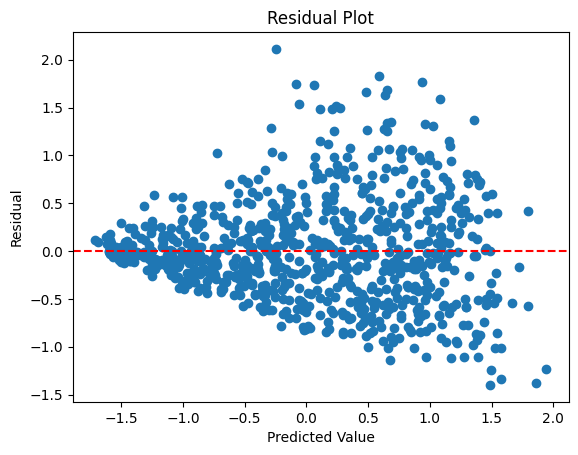

In [ ]:
poly = PolynomialFeatures(degree = 2)
X_poly = poly.fit_transform(X_train)
model = LinearRegression()
model.fit(X_poly, y_train)

X_val_poly = poly.transform(X_test)
y_pred = model.predict(X_val_poly)


residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Value")
plt.ylabel("Residual")
plt.show()


<ipython-input-557-77be03960dcb>:5: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




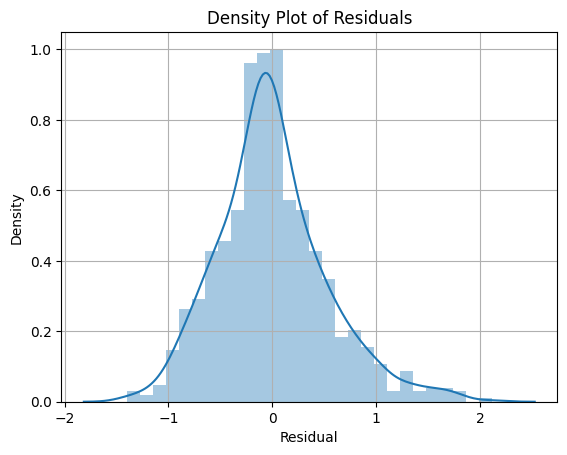

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.distplot(residuals)

plt.title("Density Plot of Residuals")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.grid(True)

plt.show()

# Polynomial regression with PCA = 2

In [ ]:
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X_trainPCA)

    model = LinearRegression()
    model.fit(X_poly, y_train)

    # Validate on the validation set
    X_val_poly = poly.transform(X_testPCA)
    y_pred = model.predict(X_val_poly)

    MSE = mean_squared_error(y_test, y_pred)
    MAE = mean_absolute_error(y_test, y_pred)
    RMSE = root_mean_squared_error(y_test, y_pred)

    print(f"MSE: {MSE} ,MAE: {MAE} ,RMSE: {RMSE}")

MSE: 0.3209987403349717 ,MAE: 0.42775153653624004 ,RMSE: 0.566567507306033


## Polynomial regression residual plot and Density graph

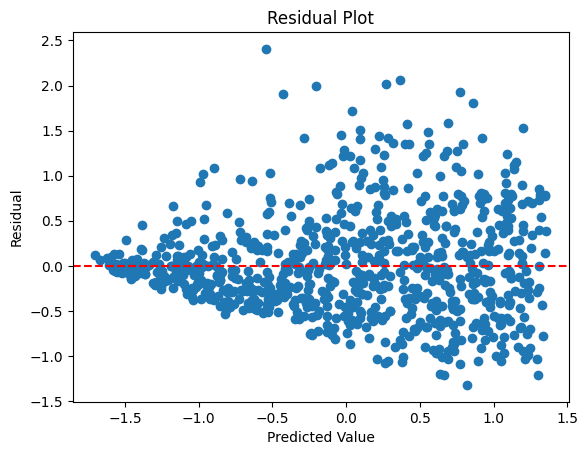

In [ ]:
poly = PolynomialFeatures(degree = 2) # should add the plot of multiple degrees ?
X_poly = poly.fit_transform(X_trainPCA)
model = LinearRegression()
model.fit(X_poly, y_train)

X_val_poly = poly.transform(X_testPCA)
y_pred = model.predict(X_val_poly)


residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Value")
plt.ylabel("Residual")
plt.show()

<ipython-input-560-b944b688f133>:7: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




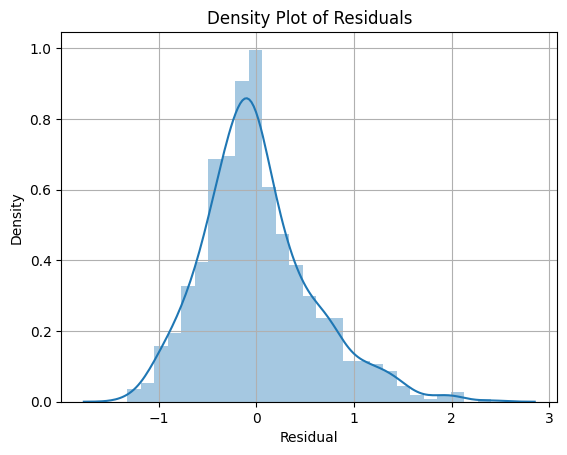

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you already have predictions and residuals calculated

# Use seaborn for density plot
sns.distplot(residuals)

# Customize the plot (optional)
plt.title("Density Plot of Residuals")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.grid(True)  # Add grid lines for better readability

plt.show()

#Polynomial Regression of degree 2, PCA = 2 visualization

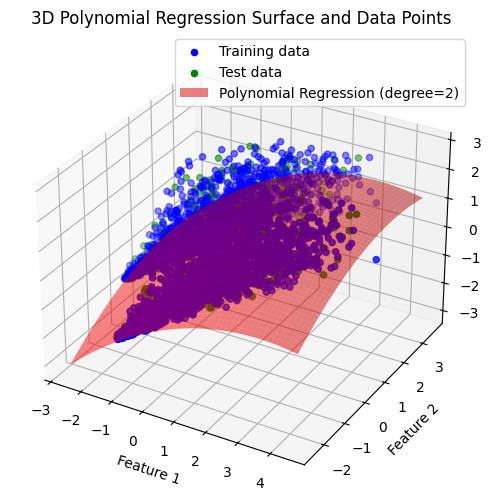

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

degree = 2
poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(X_trainPCA)
model = LinearRegression()
model.fit(X_train_poly, y_train)

X_range1 = np.linspace(min(X_trainPCA[:, 0].min(), X_testPCA[:, 0].min()), max(X_trainPCA[:, 0].max(), X_testPCA[:, 0].max()), 100)
X_range2 = np.linspace(min(X_trainPCA[:, 1].min(), X_testPCA[:, 1].min()), max(X_trainPCA[:, 1].max(), X_testPCA[:, 1].max()), 100)

X1, X2 = np.meshgrid(X_range1, X_range2)
X_range = np.vstack([X1.ravel(), X2.ravel()]).T

X_range_poly = poly.transform(X_range)
y_range_pred = model.predict(X_range_poly).reshape(X1.shape)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_trainPCA[:, 0], X_trainPCA[:, 1], y_train, color='blue', label='Training data')

ax.scatter(X_testPCA[:, 0], X_testPCA[:, 1], y_test, color='green', label='Test data')

ax.plot_surface(X1, X2, y_range_pred, color='red', alpha=0.5, label=f'Polynomial Regression (degree={degree})')

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Target y')
ax.set_title('3D Polynomial Regression Surface and Data Points')

ax.legend()

plt.show()



# Polynomial regression with PCA = 6

In [ ]:
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X_trainPCA6)

    model = LinearRegression()
    model.fit(X_poly, y_train)

    # Validate on the validation set
    X_val_poly = poly.transform(X_testPCA6)
    y_pred = model.predict(X_val_poly)

    MSE = mean_squared_error(y_test, y_pred)
    MAE = mean_absolute_error(y_test, y_pred)
    RMSE = root_mean_squared_error(y_test, y_pred)

    print(f"MSE: {MSE} ,MAE: {MAE} ,RMSE: {RMSE}")

MSE: 0.3246190447411817 ,MAE: 0.43119891478338757 ,RMSE: 0.5697534947160761


## Polynomial regression residual plot and Density graph

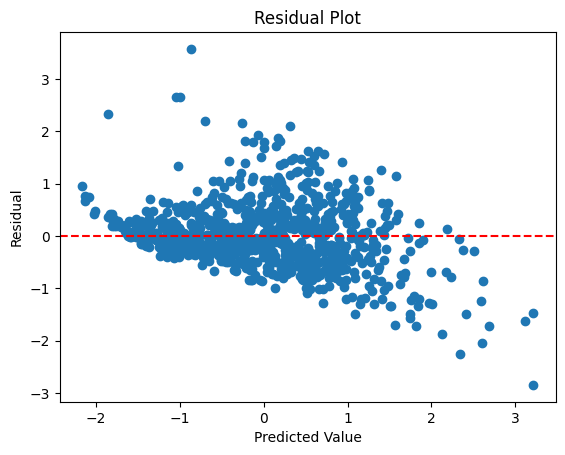

In [ ]:
poly = PolynomialFeatures(degree = 6)
X_poly = poly.fit_transform(X_trainPCA6)
model = LinearRegression()
model.fit(X_poly, y_train)

X_val_poly = poly.transform(X_testPCA6)
y_pred = model.predict(X_val_poly)


residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Value")
plt.ylabel("Residual")
plt.show()

<ipython-input-564-b944b688f133>:7: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




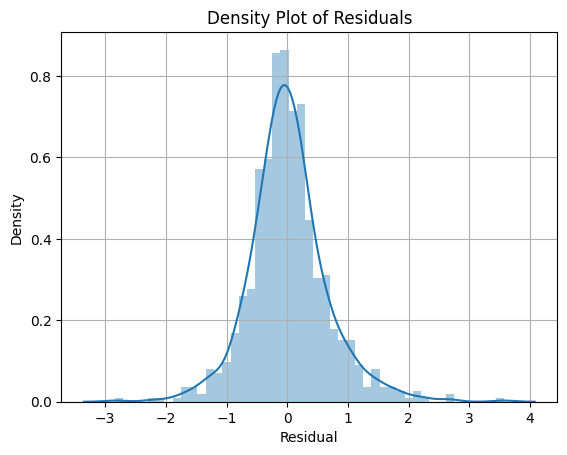

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you already have predictions and residuals calculated

# Use seaborn for density plot
sns.distplot(residuals)

# Customize the plot (optional)
plt.title("Density Plot of Residuals")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.grid(True)  # Add grid lines for better readability

plt.show()

#Laso Regression Pynomial degree 2 without PCA , Alpha =50

In [ ]:
from sklearn.linear_model import Lasso

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Apply Lasso regression
lasso_model = Lasso(alpha=50, max_iter=1000, tol=0.001)
lasso_model.fit(X_train_poly, y_train)

# Predict on the test set
y_pred = lasso_model.predict(X_test_poly)


MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)

print("Lasso Regression Evaluation:")
print(f"MSE: {MSE} ,MAE: {MAE} ,RMSE: {RMSE}")


Lasso Regression Evaluation:
MSE: 0.99005368513794 ,MAE: 0.8292262225041667 ,RMSE: 0.9950144145377694


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names



#Laso Regression Pynomial degree 2 without PCA , Alpha =0.1

In [ ]:
from sklearn.linear_model import Lasso

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Apply Lasso regression
lasso_model = Lasso(alpha=0.1, max_iter=1000, tol=0.001)
lasso_model.fit(X_train_poly, y_train)

# Predict on the test set
y_pred = lasso_model.predict(X_test_poly)


MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)

print("Lasso Regression Evaluation:")
print(f"MSE: {MSE} ,MAE: {MAE} ,RMSE: {RMSE}")


Lasso Regression Evaluation:
MSE: 0.3296945889440393 ,MAE: 0.4463814344910721 ,RMSE: 0.5741903769169588


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names



#Laso Regression Pynomial degree 2 with PCA = 2

In [ ]:
from sklearn.linear_model import Lasso

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_trainPCA)
X_test_poly = poly.transform(X_testPCA)

# Apply Lasso regression
lasso_model = Lasso(alpha=0.1, max_iter=1000, tol=0.001)
lasso_model.fit(X_train_poly, y_train)

# Predict on the test set
y_pred = lasso_model.predict(X_test_poly)


MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)

print("Lasso Regression Evaluation:")
print(f"MSE: {MSE} ,MAE: {MAE} ,RMSE: {RMSE}")


Lasso Regression Evaluation:
MSE: 0.34576714118944213 ,MAE: 0.4596606197518088 ,RMSE: 0.5880196775529218


#Laso Regression Pynomial degree 2 with PCA = 2 Visualization

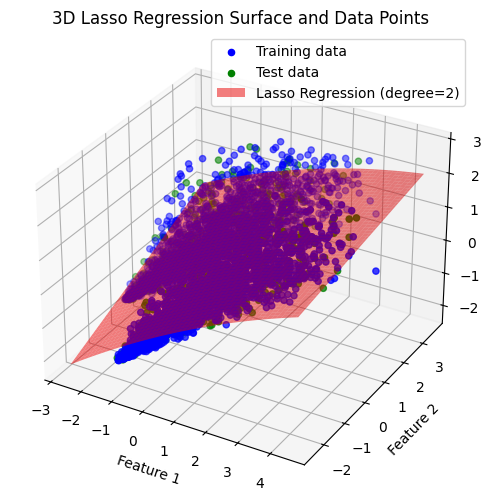

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso
from mpl_toolkits.mplot3d import Axes3D  # For 3D plotting

degree = 2
poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(X_trainPCA)
model = Lasso(alpha=0.1)  # Lasso with alpha regularization parameter
model.fit(X_train_poly, y_train)

# Generate predictions for the training and test set
X_range1 = np.linspace(min(X_trainPCA[:, 0].min(), X_testPCA[:, 0].min()), max(X_trainPCA[:, 0].max(), X_testPCA[:, 0].max()), 100)
X_range2 = np.linspace(min(X_trainPCA[:, 1].min(), X_testPCA[:, 1].min()), max(X_trainPCA[:, 1].max(), X_testPCA[:, 1].max()), 100)

# Create a meshgrid for the 2D feature space
X1, X2 = np.meshgrid(X_range1, X_range2)
X_range = np.vstack([X1.ravel(), X2.ravel()]).T  # Flatten and combine into 2D array for prediction

# Apply polynomial transformation
X_range_poly = poly.transform(X_range)
y_range_pred = model.predict(X_range_poly).reshape(X1.shape)  # Reshape for plotting

# Plotting in 3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot original training data (scatter plot)
ax.scatter(X_trainPCA[:, 0], X_trainPCA[:, 1], y_train, color='blue', label='Training data')

# Plot original test data (scatter plot)
ax.scatter(X_testPCA[:, 0], X_testPCA[:, 1], y_test, color='green', label='Test data')

# Plot the polynomial regression surface (boundary)
ax.plot_surface(X1, X2, y_range_pred, color='red', alpha=0.5, label=f'Lasso Regression (degree={degree})')

# Labels and title
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Target y')
ax.set_title('3D Lasso Regression Surface and Data Points')

# Show legend
ax.legend()

# Show plot
plt.show()


#Laso Regression Pynomial degree 2 PCA = 6

In [ ]:
from sklearn.linear_model import Lasso

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_trainPCA6)
X_test_poly = poly.transform(X_testPCA6)

# Apply Lasso regression
lasso_model = Lasso(alpha=0.1, max_iter=1000, tol=0.001)
lasso_model.fit(X_train_poly, y_train)

# Predict on the test set
y_pred = lasso_model.predict(X_test_poly)


MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)

print("Lasso Regression Evaluation:")
print(f"MSE: {MSE} ,MAE: {MAE} ,RMSE: {RMSE}")


Lasso Regression Evaluation:
MSE: 0.34576714118944213 ,MAE: 0.4596606197518088 ,RMSE: 0.5880196775529218


#Ridge Pynomial Regression degree 2 without PCA

In [ ]:
from sklearn.linear_model import Ridge

poly = PolynomialFeatures(degree=2)  # Adjust the degree as needed
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Apply Ridge regression
ridge_model = Ridge(alpha=0.1, max_iter=1000)  # Adjust alpha as needed
ridge_model.fit(X_train_poly, y_train)

# Predict on the test set
y_pred = ridge_model.predict(X_test_poly)

MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)

print("Ridge Regression Evaluation:")
print(f"MSE: {MSE} ,MAE: {MAE} ,RMSE: {RMSE}")


Ridge Regression Evaluation:
MSE: 0.28058544379791583 ,MAE: 0.39763748762921897 ,RMSE: 0.5297031657427732


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names



#Ridge Pynomial Regression degree 2 without PCA , Alpha=50

ridge is much better than lasso as without regulation the MSE was 0.0126
with ridge 0.0125
with lasso 0.0508

In [ ]:
from sklearn.linear_model import Ridge

poly = PolynomialFeatures(degree=2)  # Adjust the degree as needed
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Apply Ridge regression
ridge_model = Ridge(alpha=50, max_iter=1000)  # Adjust alpha as needed
ridge_model.fit(X_train_poly, y_train)

# Predict on the test set
y_pred = ridge_model.predict(X_test_poly)

MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)

print("Ridge Regression Evaluation:")
print(f"MSE: {MSE} ,MAE: {MAE} ,RMSE: {RMSE}")


Ridge Regression Evaluation:
MSE: 0.28083021097340133 ,MAE: 0.3980140641096052 ,RMSE: 0.529934157205781


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names



#Ridge Pynomial Regression degree 2 wih PCA = 2

In [ ]:
from sklearn.linear_model import Ridge

poly = PolynomialFeatures(degree=2)  # Adjust the degree as needed
X_train_poly = poly.fit_transform(X_trainPCA)
X_test_poly = poly.transform(X_testPCA)

# Apply Ridge regression
ridge_model = Ridge(alpha=50, max_iter=1000)  # Adjust alpha as needed
ridge_model.fit(X_train_poly, y_train)

# Predict on the test set
y_pred = ridge_model.predict(X_test_poly)

MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)

print("Ridge Regression Evaluation:")
print(f"MSE: {MSE} ,MAE: {MAE} ,RMSE: {RMSE}")


Ridge Regression Evaluation:
MSE: 0.32104910296969885 ,MAE: 0.42817657961327205 ,RMSE: 0.5666119509591188


ridge is much better than lasso as without regulation the MSE was 0.0126
with ridge 0.0125
with lasso 0.0508

# Ridge Polynomial Regression of degree 2, PCA = 2 visualization

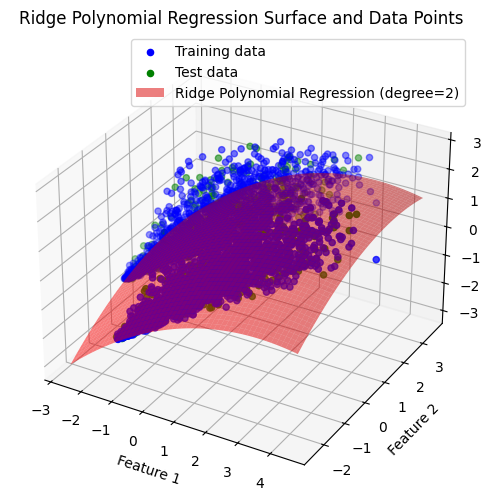

In [ ]:
degree = 2
poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(X_trainPCA)

# Use Ridge regression with a regularization strength (alpha)
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train_poly, y_train)

# Generate predictions for the training and test set
X_range1 = np.linspace(min(X_trainPCA[:, 0].min(), X_testPCA[:, 0].min()), max(X_trainPCA[:, 0].max(), X_testPCA[:, 0].max()), 100)
X_range2 = np.linspace(min(X_trainPCA[:, 1].min(), X_testPCA[:, 1].min()), max(X_trainPCA[:, 1].max(), X_testPCA[:, 1].max()), 100)

# Create a meshgrid for the 2D feature space
X1, X2 = np.meshgrid(X_range1, X_range2)
X_range = np.vstack([X1.ravel(), X2.ravel()]).T  # Flatten and combine into 2D array for prediction

# Apply polynomial transformation to the meshgrid
X_range_poly = poly.transform(X_range)
y_range_pred = ridge_model.predict(X_range_poly).reshape(X1.shape)  # Reshape for plotting

# Plotting in 3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot original training data (scatter plot)
ax.scatter(X_trainPCA[:, 0], X_trainPCA[:, 1], y_train, color='blue', label='Training data')

# Plot original test data (scatter plot)
ax.scatter(X_testPCA[:, 0], X_testPCA[:, 1], y_test, color='green', label='Test data')

# Plot the polynomial regression surface (boundary)
ax.plot_surface(X1, X2, y_range_pred, color='red', alpha=0.5, label=f'Ridge Polynomial Regression (degree={degree})')

# Labels and title
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Target y')
ax.set_title('Ridge Polynomial Regression Surface and Data Points')

# Show legend
ax.legend()

# Show plot
plt.show()


#Ridge Pynomial Regression degree 2 with PCA = 6

In [ ]:
from sklearn.linear_model import Ridge

poly = PolynomialFeatures(degree=2)  # Adjust the degree as needed
X_train_poly = poly.fit_transform(X_trainPCA6)
X_test_poly = poly.transform(X_testPCA6)

# Apply Ridge regression
ridge_model = Ridge(alpha=50, max_iter=1000)  # Adjust alpha as needed
ridge_model.fit(X_train_poly, y_train)

# Predict on the test set
y_pred = ridge_model.predict(X_test_poly)

MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)

print("Ridge Regression Evaluation:")
print(f"MSE: {MSE} ,MAE: {MAE} ,RMSE: {RMSE}")


Ridge Regression Evaluation:
MSE: 0.3248601212952601 ,MAE: 0.43194508058449205 ,RMSE: 0.5699650176065721


ridge is much better than lasso as without regulation the MSE was 0.0126
with ridge 0.0125
with lasso 0.0508

# Elastic Net Regression degree 2 without PCA


In [ ]:
from sklearn.linear_model import ElasticNet

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Apply ElasticNet regression
elastic_net_model = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=1000)
elastic_net_model.fit(X_train_poly, y_train)

# Predict on the test set
y_pred = elastic_net_model.predict(X_test_poly)

MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)

print("ElasticNet Regression Evaluation:")
print(f"MSE: {MSE} ,MAE: {MAE} ,RMSE: {RMSE}")


ElasticNet Regression Evaluation:
MSE: 0.2976900773904778 ,MAE: 0.4200590152869099 ,RMSE: 0.5456098215670955


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names



# Elastic Net Regression degree 2 without PCA , Alpha=50 and l1 ratio=0.3


In [ ]:
from sklearn.linear_model import ElasticNet

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Apply ElasticNet regression
elastic_net_model = ElasticNet(alpha=50 , l1_ratio=0.3, max_iter=1000)
elastic_net_model.fit(X_train_poly, y_train)

# Predict on the test set
y_pred = elastic_net_model.predict(X_test_poly)

MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)

print("ElasticNet Regression Evaluation:")
print(f"MSE: {MSE} ,MAE: {MAE} ,RMSE: {RMSE}")


ElasticNet Regression Evaluation:
MSE: 0.99005368513794 ,MAE: 0.8292262225041667 ,RMSE: 0.9950144145377694


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names



# Elastic Net Regression degree 2 with PCA = 2


In [ ]:
from sklearn.linear_model import ElasticNet

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_trainPCA)
X_test_poly = poly.transform(X_testPCA)

# Apply ElasticNet regression
elastic_net_model = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=1000)
elastic_net_model.fit(X_train_poly, y_train)

# Predict on the test set
y_pred = elastic_net_model.predict(X_test_poly)

MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)

print("Lasso Regression Evaluation:")
print(f"MSE: {MSE} ,MAE: {MAE} ,RMSE: {RMSE}")


Lasso Regression Evaluation:
MSE: 0.3312454881148832 ,MAE: 0.44442290062110096 ,RMSE: 0.575539301972405


# Elastic Net Regression degree 2 with PCA = 6


In [ ]:
from sklearn.linear_model import ElasticNet

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_trainPCA6)
X_test_poly = poly.transform(X_testPCA6)

# Apply ElasticNet regression
elastic_net_model = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=1000)
elastic_net_model.fit(X_train_poly, y_train)

# Predict on the test set
y_pred = elastic_net_model.predict(X_test_poly)

MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)

print("Lasso Regression Evaluation:")
print(f"MSE: {MSE} ,MAE: {MAE} ,RMSE: {RMSE}")


Lasso Regression Evaluation:
MSE: 0.3312454881148832 ,MAE: 0.44442290062110096 ,RMSE: 0.575539301972405


# Elastic Net Regression degree 2 with PCA = 2 Visualization


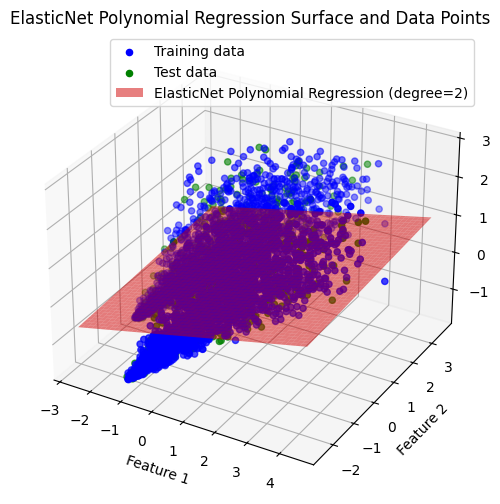

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import ElasticNet
from mpl_toolkits.mplot3d import Axes3D  # For 3D plotting

# Ensure X_trainPCA and X_testPCA are 2D arrays (for polynomial fitting)
X_trainPCA = X_trainPCA.reshape(-1, 2)  # Ensure it's 2D (2 features)
X_testPCA = X_testPCA.reshape(-1, 2)

# Fit Elastic Net regression model with polynomial features
degree = 2  # degree of the polynomial features
poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(X_trainPCA)

# Use ElasticNet regression with regularization parameters
elastic_net_model = ElasticNet(alpha=1.0, l1_ratio=0.5)  # You can adjust alpha and l1_ratio
elastic_net_model.fit(X_train_poly, y_train)

# Generate predictions for the training and test set
X_range1 = np.linspace(min(X_trainPCA[:, 0].min(), X_testPCA[:, 0].min()), max(X_trainPCA[:, 0].max(), X_testPCA[:, 0].max()), 100)
X_range2 = np.linspace(min(X_trainPCA[:, 1].min(), X_testPCA[:, 1].min()), max(X_trainPCA[:, 1].max(), X_testPCA[:, 1].max()), 100)

# Create a meshgrid for the 2D feature space
X1, X2 = np.meshgrid(X_range1, X_range2)
X_range = np.vstack([X1.ravel(), X2.ravel()]).T  # Flatten and combine into 2D array for prediction

# Apply polynomial transformation to the meshgrid
X_range_poly = poly.transform(X_range)
y_range_pred = elastic_net_model.predict(X_range_poly).reshape(X1.shape)  # Reshape for plotting

# Plotting in 3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot original training data (scatter plot)
ax.scatter(X_trainPCA[:, 0], X_trainPCA[:, 1], y_train, color='blue', label='Training data')

# Plot original test data (scatter plot)
ax.scatter(X_testPCA[:, 0], X_testPCA[:, 1], y_test, color='green', label='Test data')

# Plot the polynomial regression surface (boundary)
ax.plot_surface(X1, X2, y_range_pred, color='red', alpha=0.5, label=f'ElasticNet Polynomial Regression (degree={degree})')

# Labels and title
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Target y')
ax.set_title('ElasticNet Polynomial Regression Surface and Data Points')

# Show legend
ax.legend()

# Show plot
plt.show()
